# Chapter 9: Support Vector Machines
+ "New" learning method invented by Vladamir Vapnik in the 1990's. 
+ Likely best classifier at its time, now surpassed by gradient boosted trees and neural networks.

Three different but very closely related classifiers:
* Maximal margin classifier
* Support Vector classifier
* Support vector machine

## Maximal Margin Classifier
### Hyperplane
+ An optimal hyperplane that separates classes.  
+ **Hyperplane** - For any p dimensional space, it is a p-1 dimensional flat surface. 
+ A line in 2 dimensions, a plane in three dimensions. 
+ Mathematical definition in p dimensions: $\beta_0 + \beta_1 X_1 + ... + \beta_p X_p = 0$. 
+ It divides whatever your dimension is into two pieces.




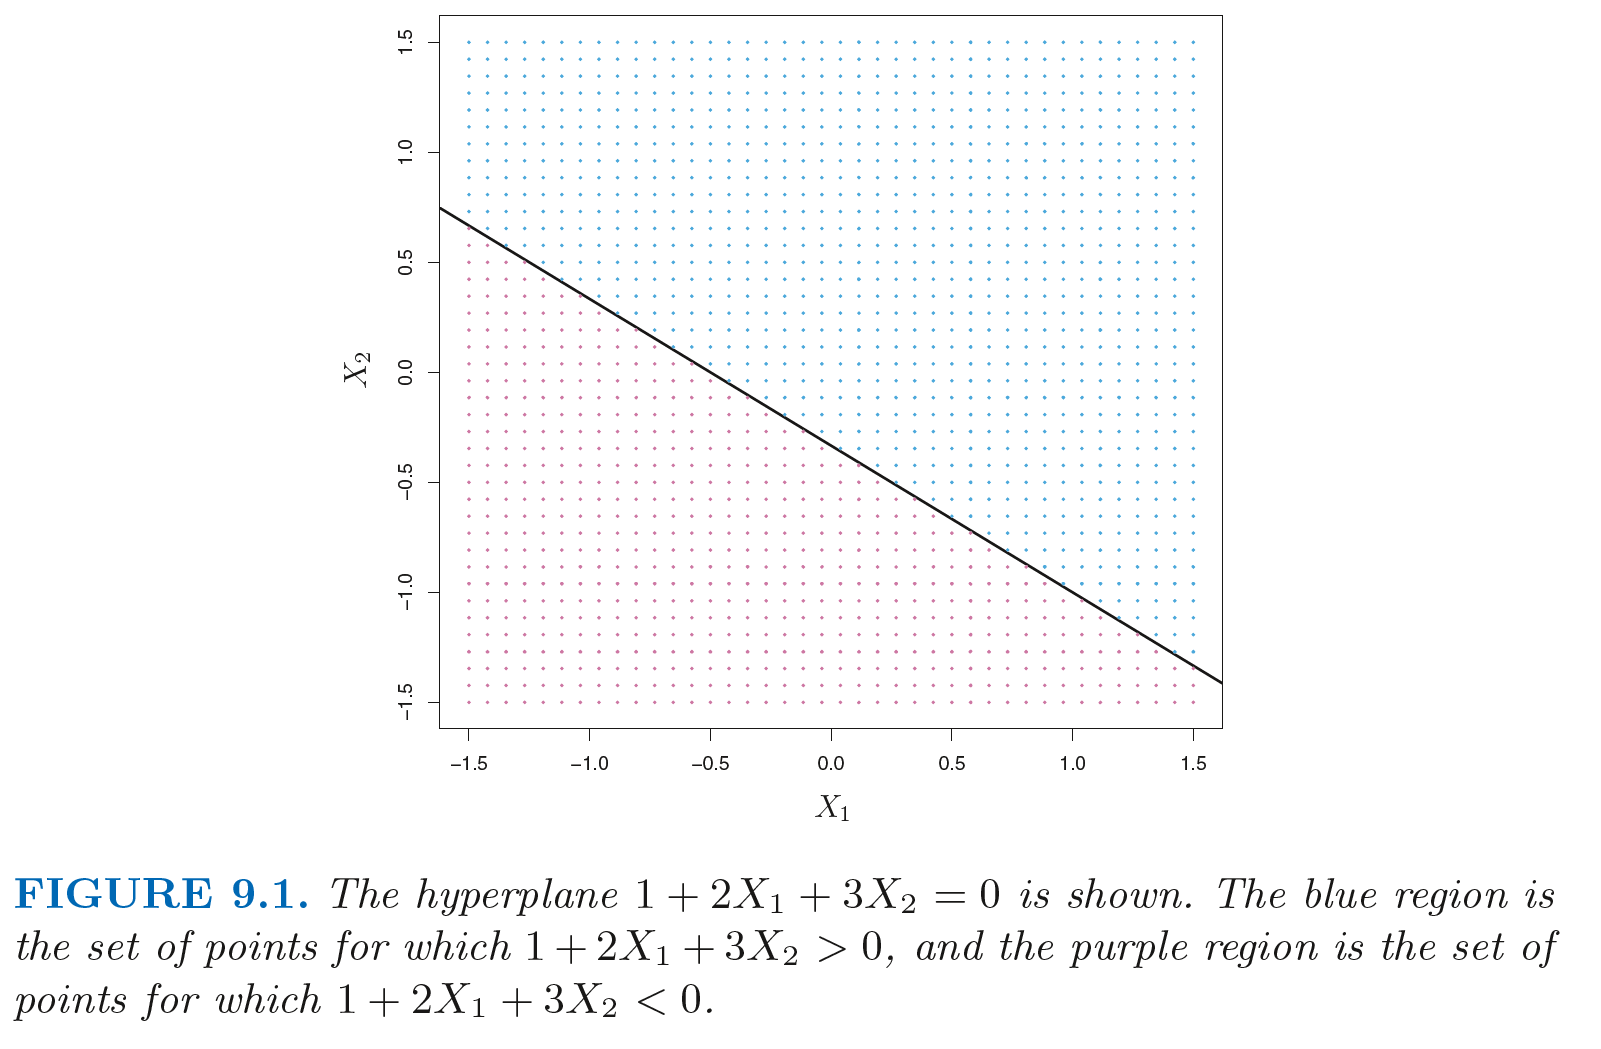

In [88]:
from IPython.display import Image
Image('images2/pw91.png', width =700)

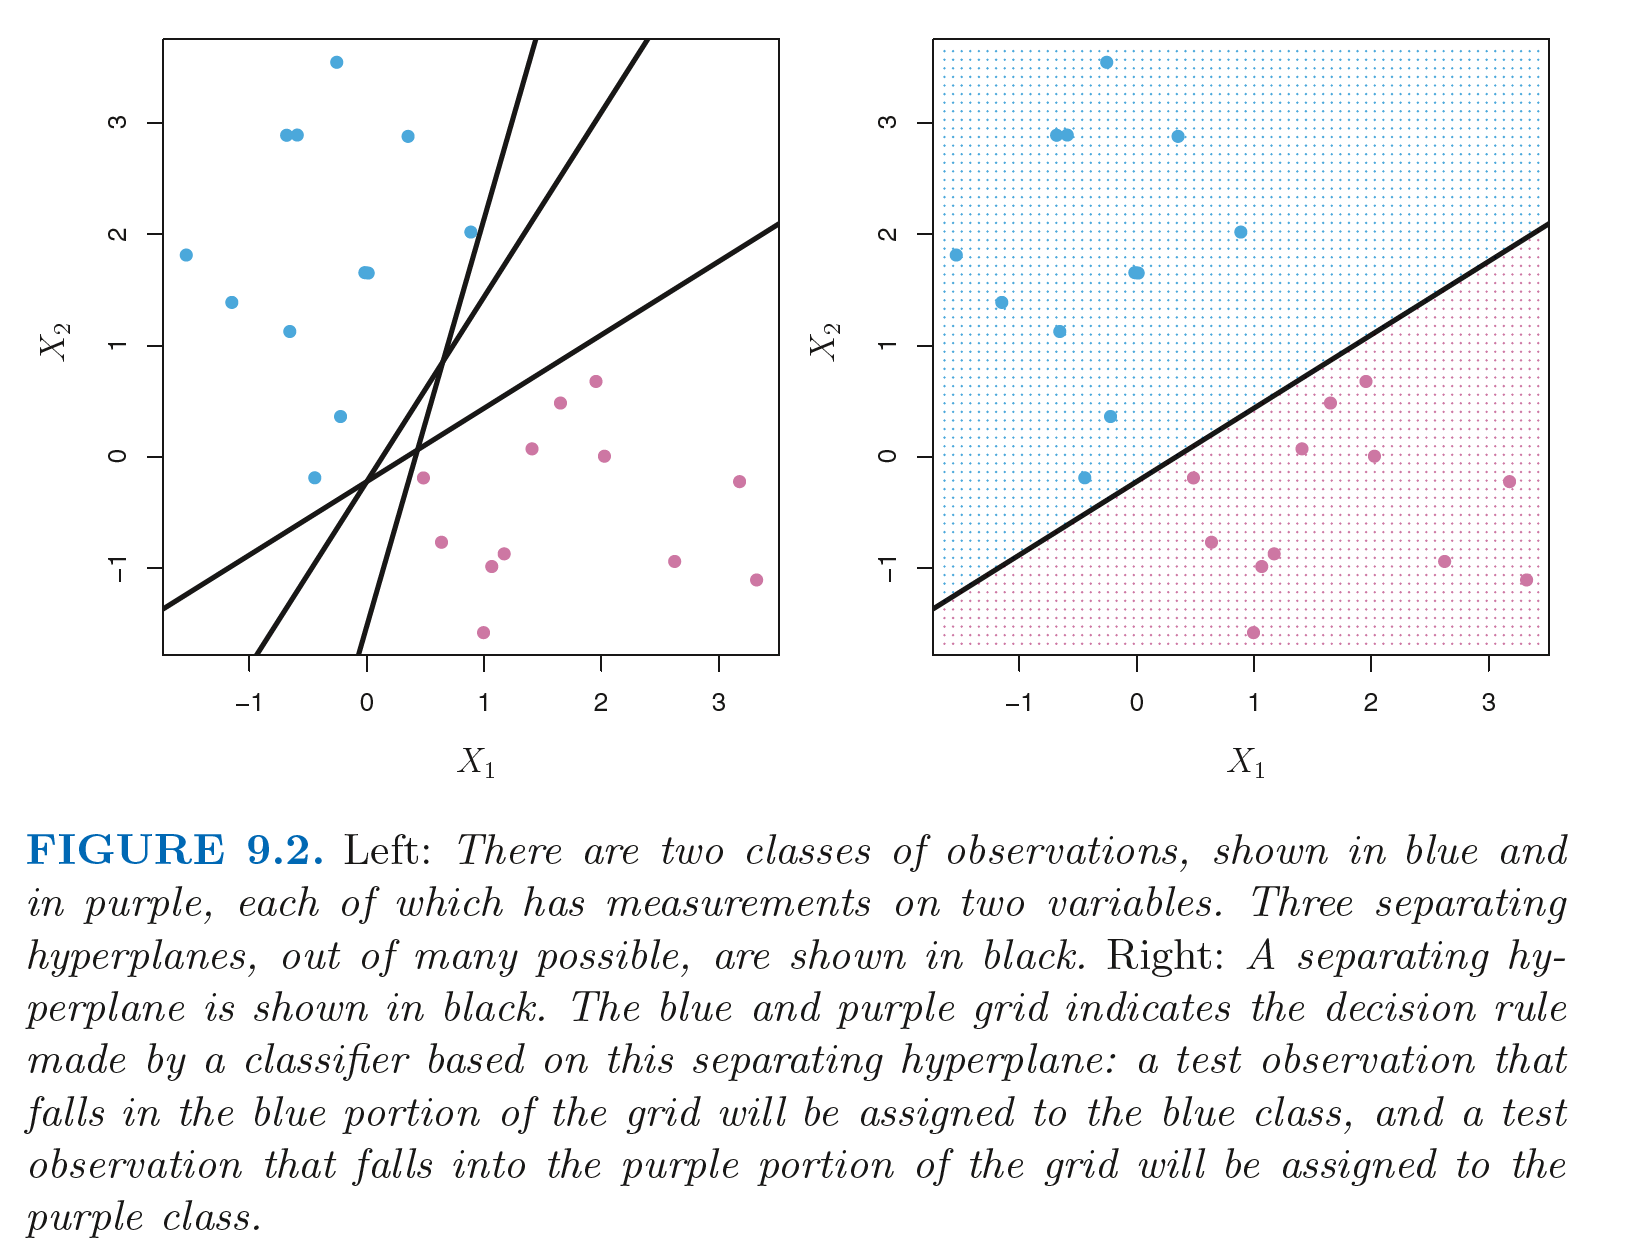

In [89]:
Image('images2/pw92.png', width =700)

### Classification Using a Separating Hyperplane
+ Suppose we have  a $n \times p$ data matrix $\textbf{X}$
$$x_1 = \left[\begin{array}{c} x_{11} \\ \vdots \\ x_{1p} \end{array} \right], \; \ldots, \; x_n = \left[\begin{array}{c} x_{n1} \\ \vdots \\ x_{np} \end{array} \right]$$
and these observations fall into two classes, $y_1, \ldots, y_n \in \left\{-1,1\right\}$.
+ This approach is based upon the concept of **separating hyperplane**.
+ Consider the left hand panel in Fig 9.2, where the separating hyperplane has the property
$$\begin{eqnarray} \beta_0 + \beta_1x_{i1}+ \ldots + \beta_px_{ip} > 0 & \textrm{ if } & y_i=1 \\
  \beta_0 + \beta_1x_{i1}+ \ldots + \beta_px_{ip} < 0 & \textrm{ if } & y_i=-1 \end{eqnarray}$$
+ Multiplying both equations by $y_i$ yields $y_i(\beta_0 + \beta_1x_{i1}+ \ldots + \beta_px_{ip}) > 0$ for any correctly classified observation.
+ A test observation, $x^*$, can be classified based on the sign of $f(x^*)$ (positive (class 1) or negative (class -1)).
+ The magnitude of $f(x^*)$ can be used to measure how confident we are about the class assignment for $x^*$.

### The maximal margin classifier
+ If the data is perfectly separable then an infinite number of hyperplanes will exist that can perfectly separate the data. 
+ A natural choice is to choose a hyperplane that maximizes the distance from each observation (training) to the hyperplane - one that has a large margin - the maximum margin.

### What defines maximum margin?
+ In the linearly separable case we find the line that has the maximum margin between the two classes. 
+ The maximum margin is defined as the distance of the closet point to the separating hyperplane. 
+ So, we are maximizing the minimum distance from the hyperplane. 
+ All other points are of no consequence which is a bit scary but it happens to work well. 
+ These minimum distance points are called the **support vectors**.

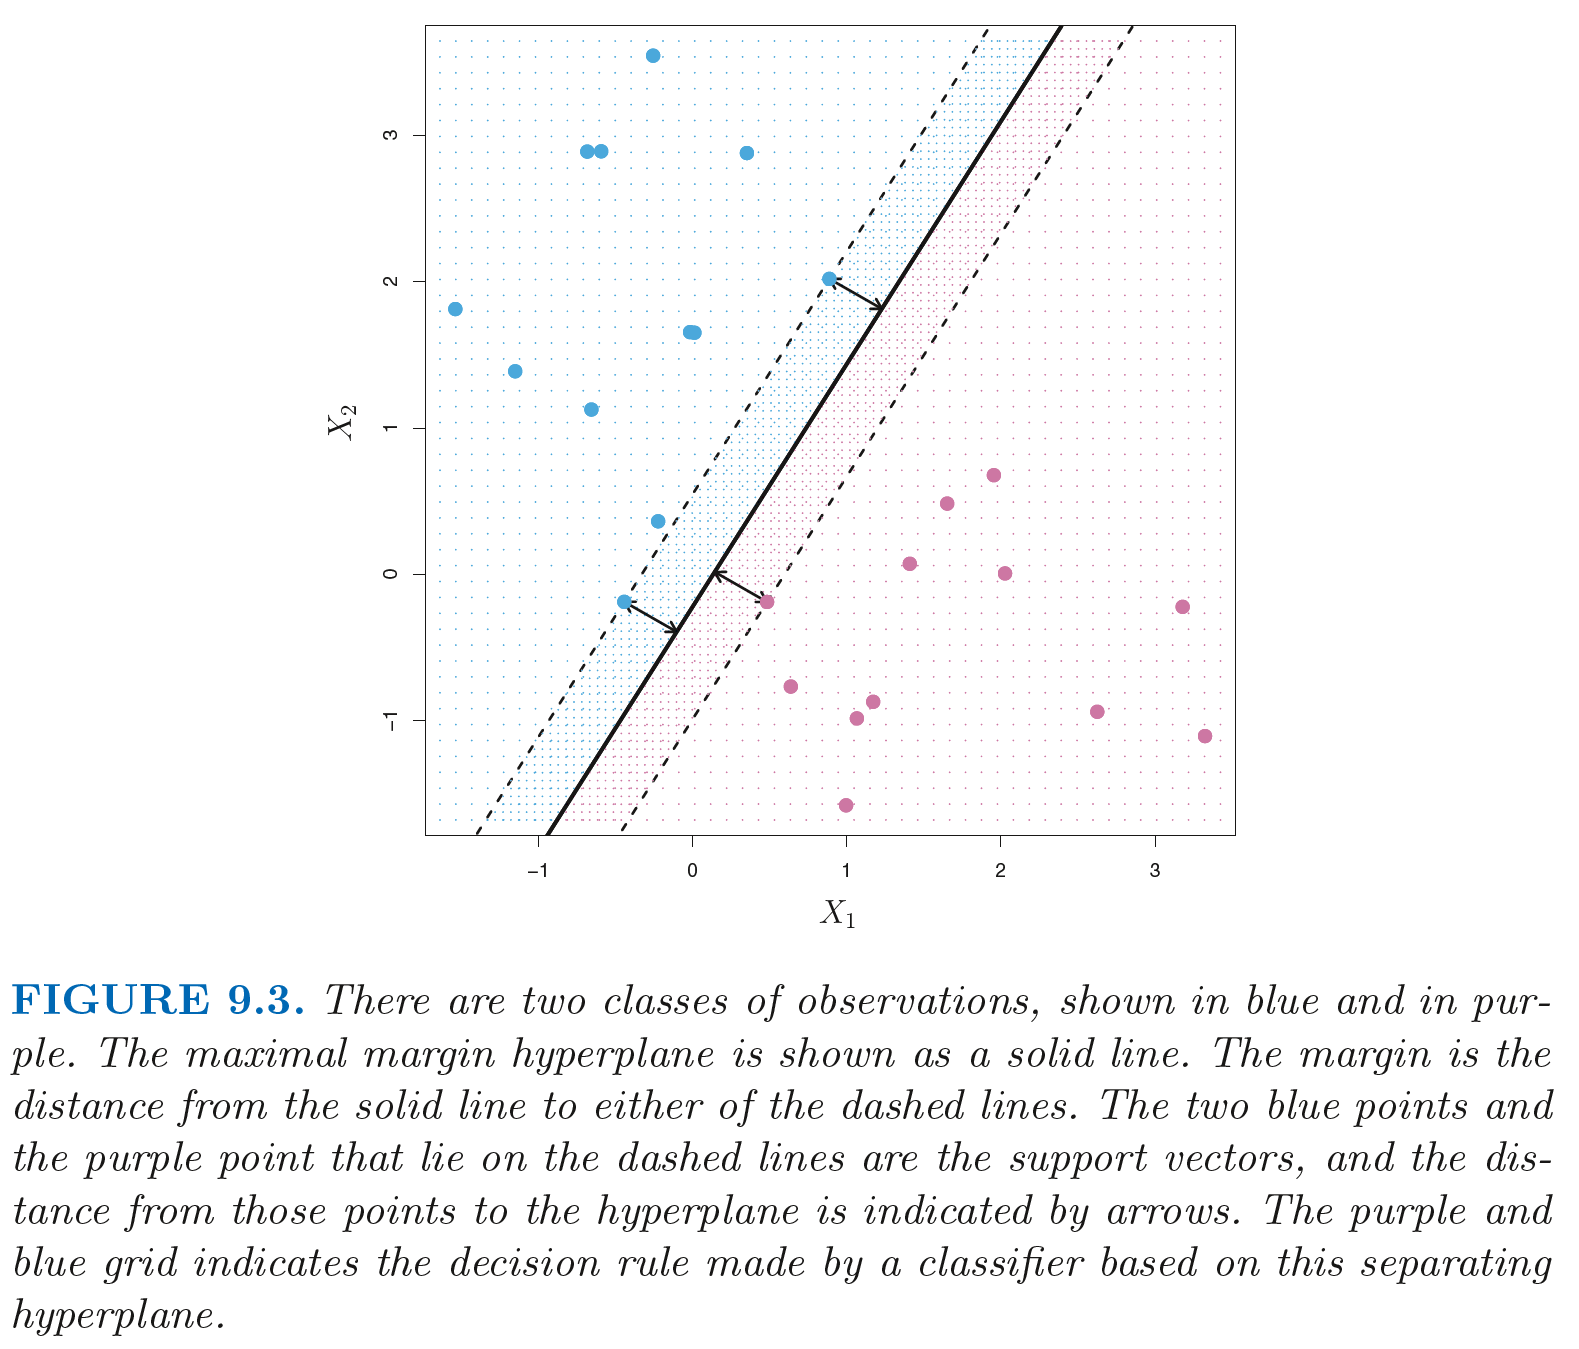

In [90]:
Image('images2/pw93.png', width =600)

### Contruction of the Maximal Margin Classifier
+ Set of training observations, $x_1, \ldots, x_n \in \mathbb{R}^p$
+ Associated class labels, $y_1, \ldots, y_n \in \left\{ -1, 1 \right\}$
+ The maximal margin hyperplane is the solution to:
$$    \max_{\beta_0, \ldots, \beta_p, M}{M} $$
$$   \textrm{subject to } \sum_{j=1}^p{\beta_j^2} = 1 $$
$$   y_i(\beta_0 + \beta_1 x_{i1} + \ldots + \beta_p x_{ip}) \geq M \quad \forall i=1, \ldots, n $$
   where $M$ is the width of the margin.





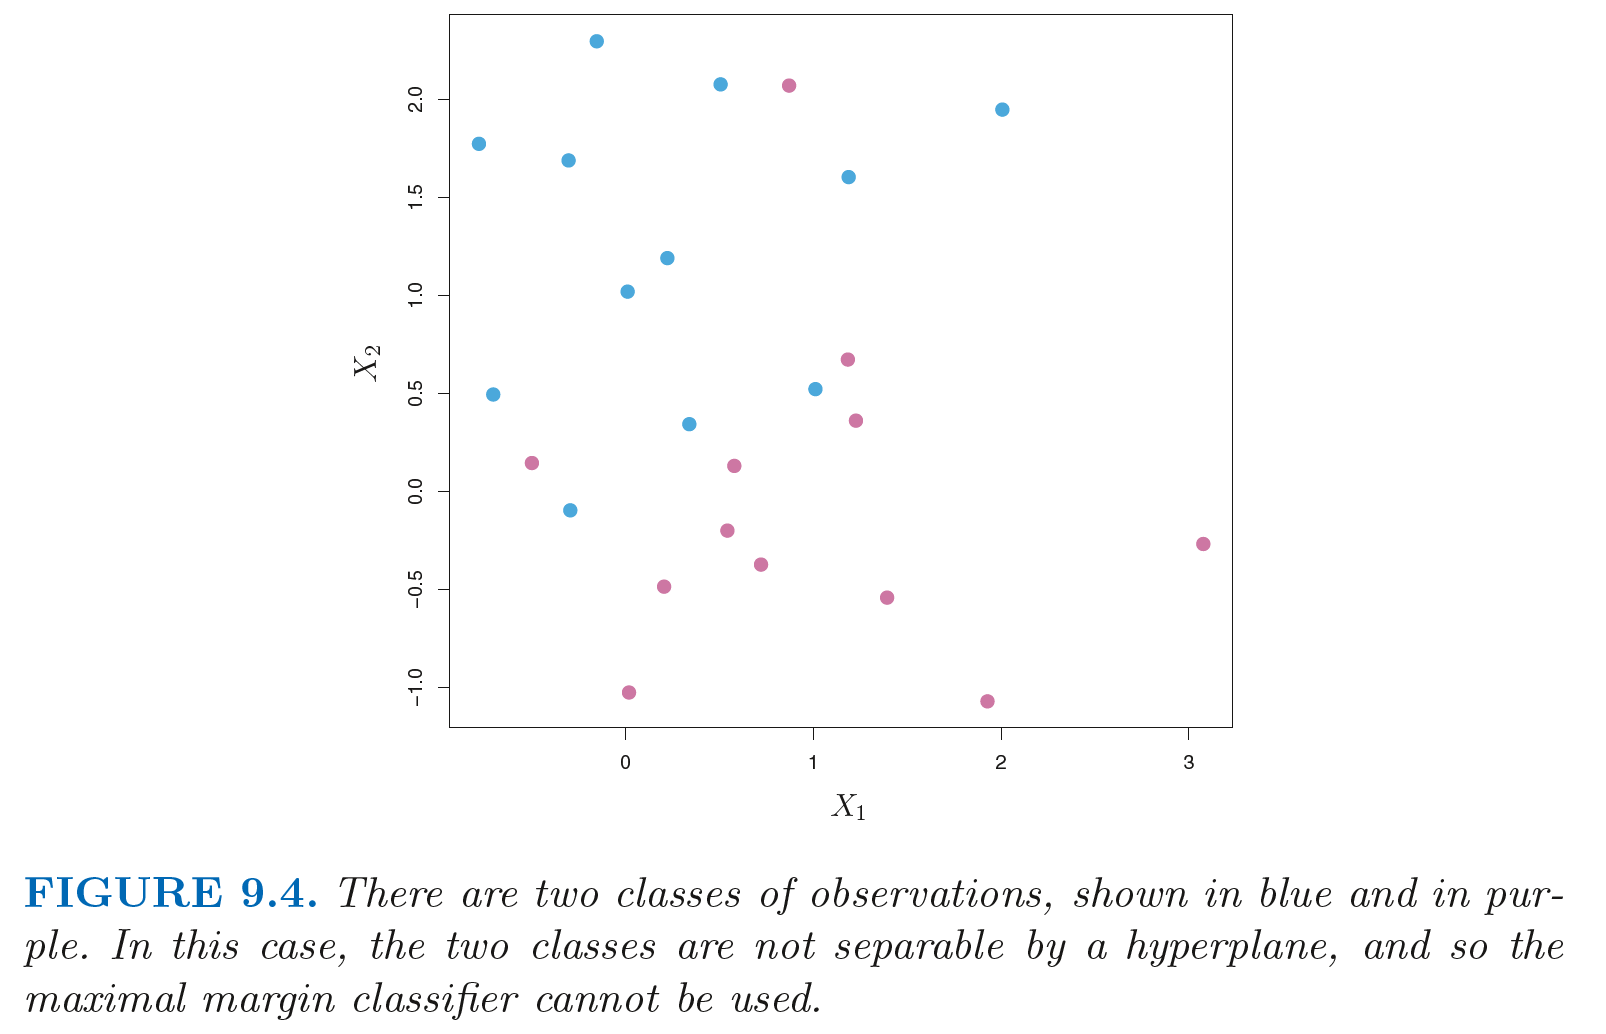

In [91]:
Image('images2/pw94.png', width =700)

## Support Vector Classifiers
+ If the data is not linearly separable then no hyperplane can separate the data and thus no margin can exist. 
+ This case is most common with real data. 
+ The maximum margin classifier is very sensitive to single data points. 
+ The hyperplane can change drastically with the addition of one new data point. 
+ To help combat this type of overfitting and to allow for non-separable classification we can use a soft margin. 
+ We allow some observation to be on the wrong side of the hyperplane or within the margin. 
+ This margin violation makes the margin 'soft'.
+ This will provide:
    + Greater robustness to individual observations
    + Better classification of most of the training observations
+ Also known as **soft margin classifier**


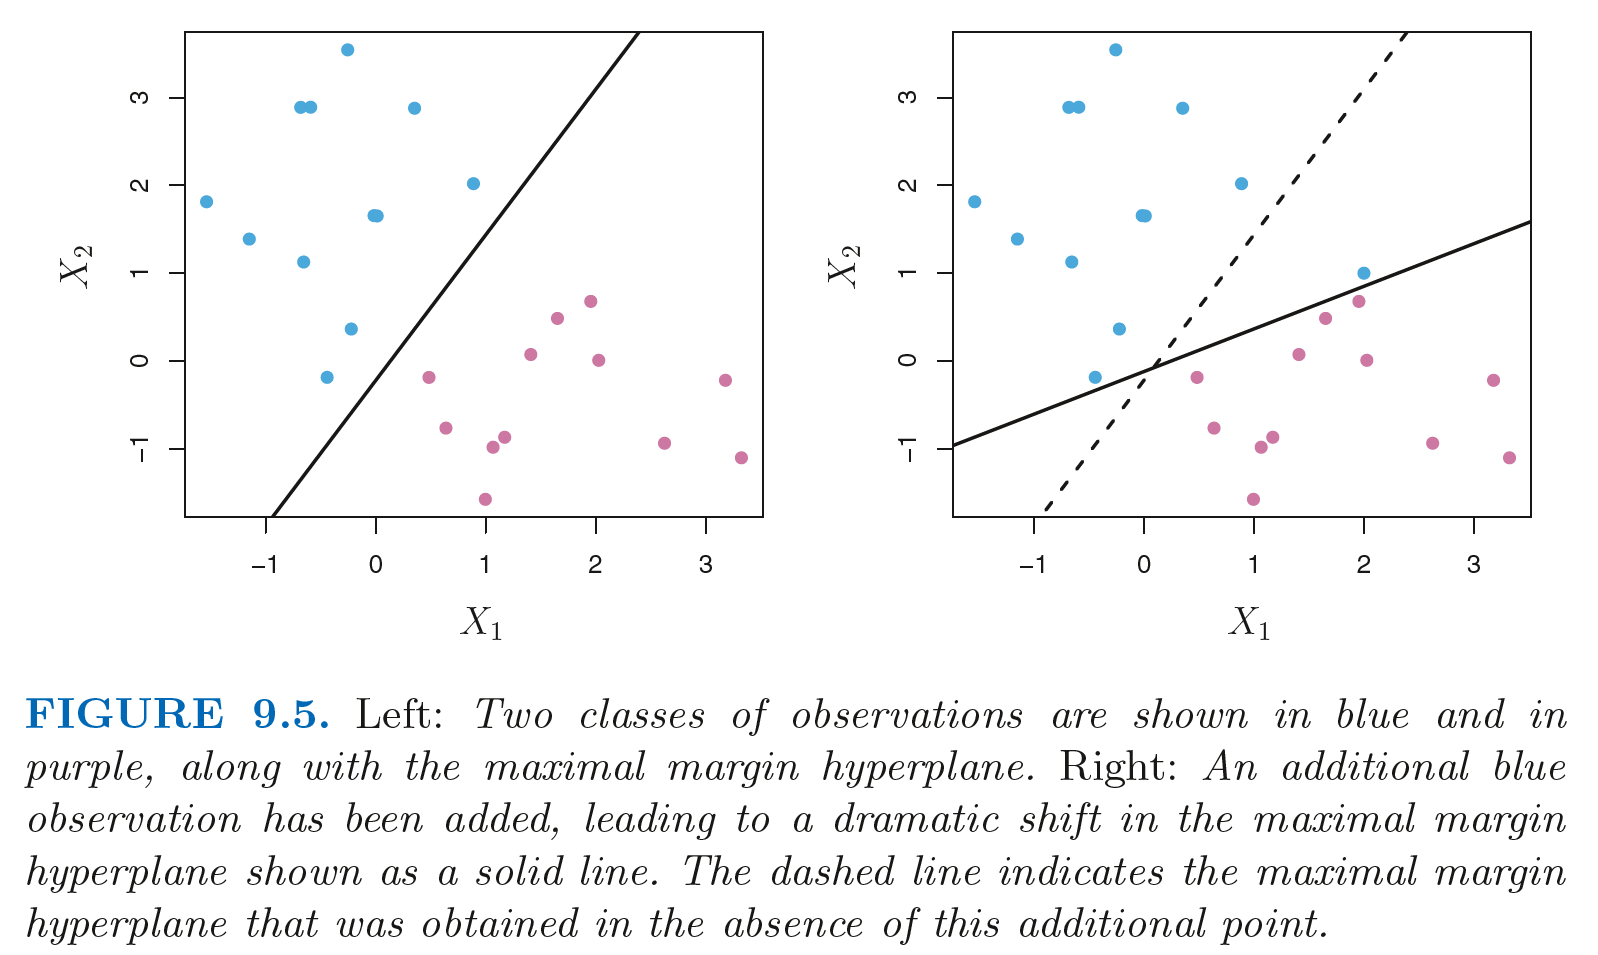

In [92]:
Image('images2/pw95.png', width =700)

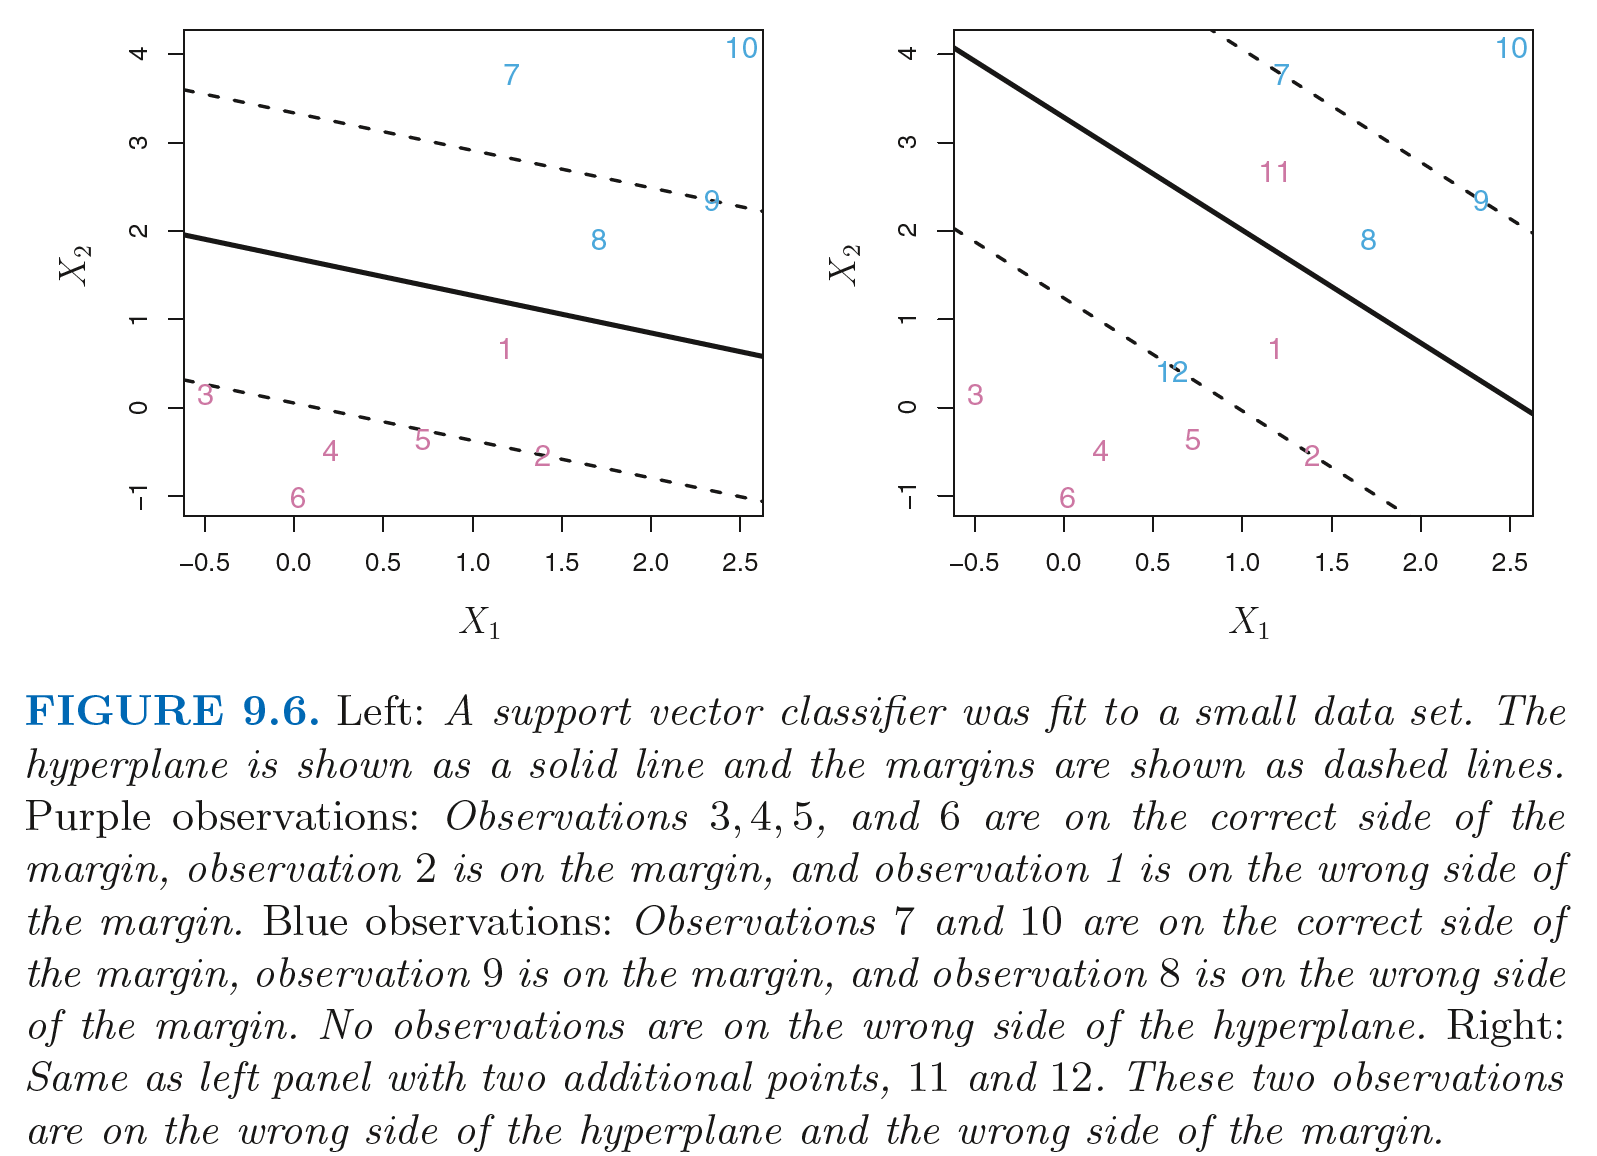

In [93]:
Image('images2/pw96.png', width =700)

+ The hyperplane is chosen to correctly separate most of the training observations into the two classes, but may misclassify a few observations.
+ The problem formulation is tweaked such that we allow for some total amount of error, C. 
$$    \max_{\beta_0, \ldots, \beta_p, \epsilon_1, \ldots , \epsilon_n M}{M} $$
$$   \textrm{subject to } \sum_{j=1}^p{\beta_j^2} = 1 $$
$$   y_i(\beta_0 + \beta_1 x_{i1} + \ldots + \beta_p x_{ip}) \geq M(1-\epsilon_i) $$
$$   \epsilon_i \geq 0, \quad \sum_{i=1}^n{\epsilon_i} \leq C$$
+ We seek to make $M$ as large as possible.
+ The errors, $\epsilon_i$,  are called slack variables, which allow observations to be on the wrong side of the margin or hyperplane. 
$$ \begin{eqnarray} \epsilon_i = 0 & i^\textrm{th} \textrm{observation on the correct side of the margin} \\
\epsilon_i >0 & i^\textrm{th} \textrm{observation on the wrong side of the margin} \\
\epsilon_i >1 & \; i^\textrm{th} \textrm{observation on the wrong side of the hyperplane} \end{eqnarray}$$
+ C bounds the sum of the $\epsilon_i$'s
+ This total error acts as an allowance like a balance in the bank that you can spend on the amount of error you can make. 
$$ \begin{eqnarray} C = 0 & \textrm{no budget for violations to the margin} \\
C >0 & \textrm{  no more than C observations can be  on the wrong side of the hyperplane}  \end{eqnarray}$$
+ C is chosen through cross-validation.
+ Observation that lies strictly on the correct side of the margin does not affect the support vector classifier.
+ Observations that lie directly on the margin, or on the wrong side of the margin, are known as **support vectors**, which do affect the support vector classifier.

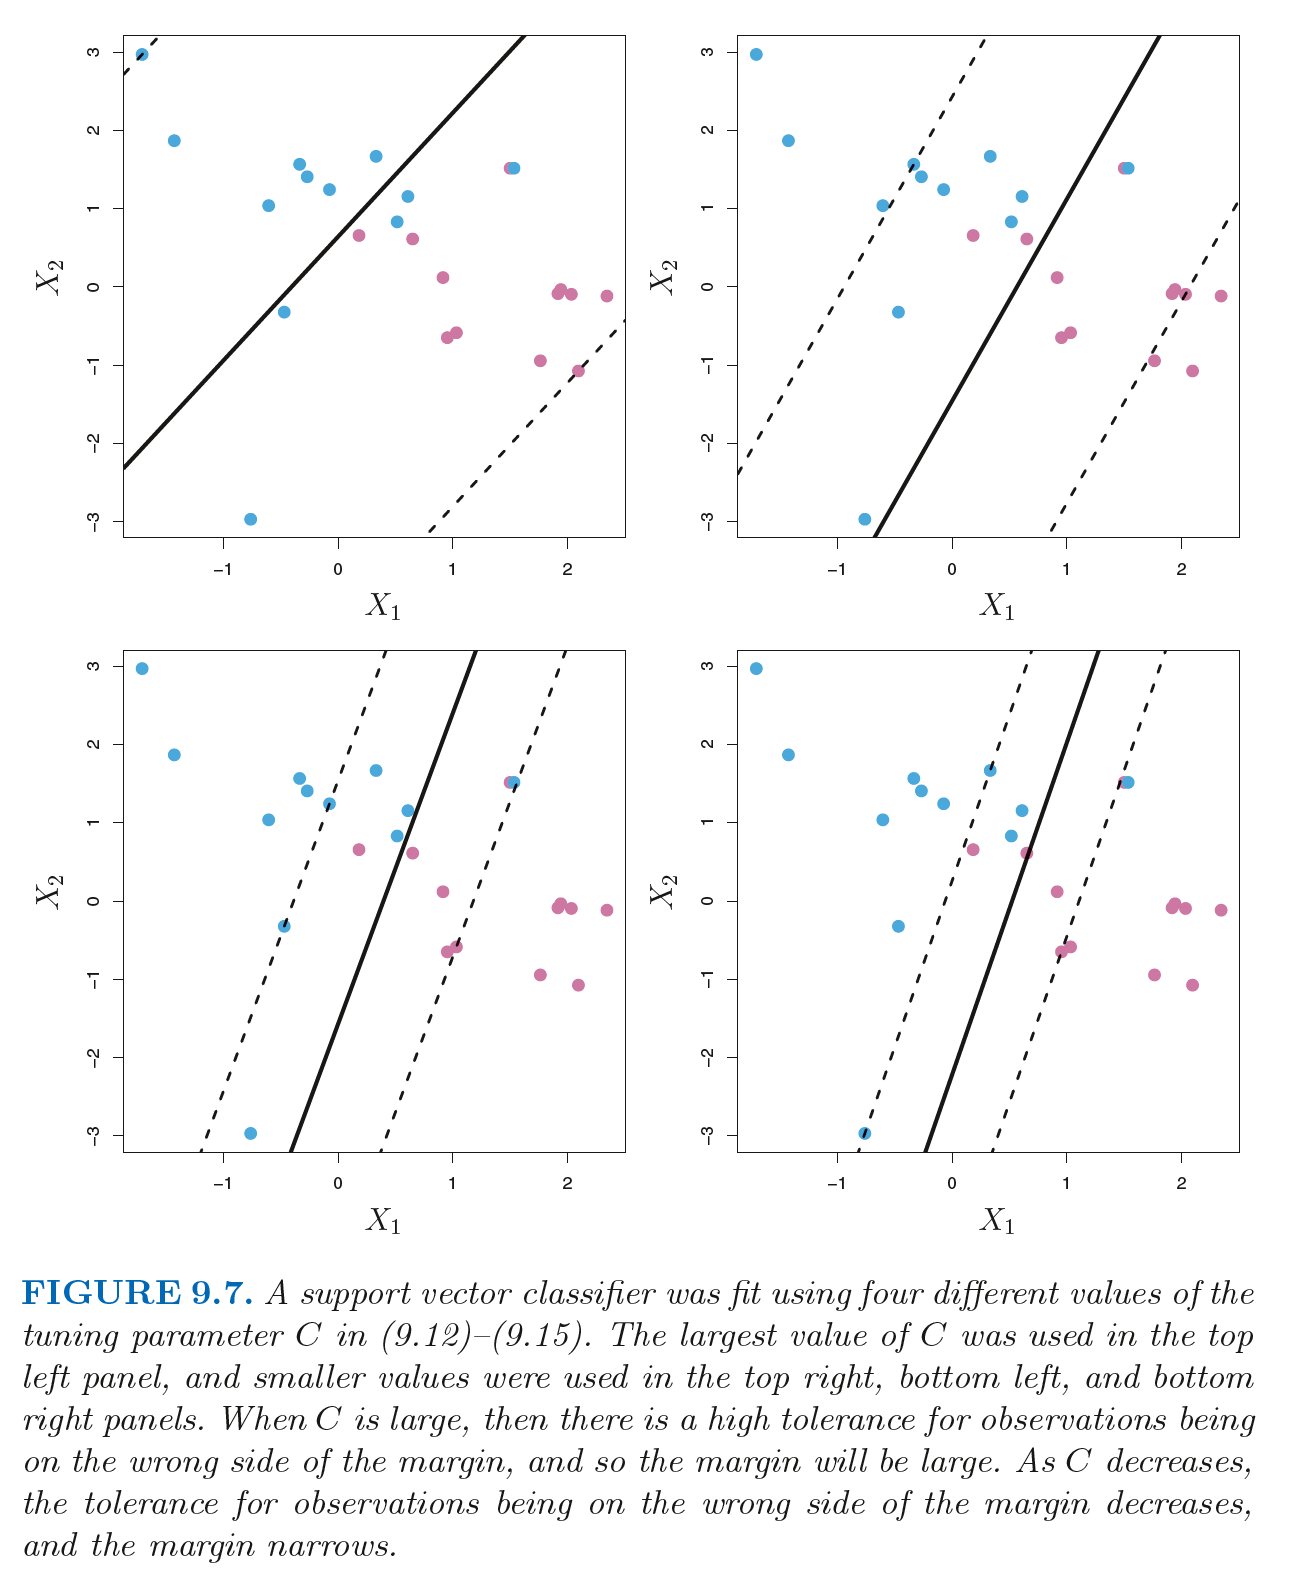

In [94]:
Image('images2/pw97.png', width =700)

### Lab

In [8]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

%matplotlib inline

# We'll define a function to draw a nice plot of an SVM
def plot_svc(svc, X, y, h=0.02, pad=0.25):
    x_min, x_max = X[:, 0].min()-pad, X[:, 0].max()+pad
    y_min, y_max = X[:, 1].min()-pad, X[:, 1].max()+pad
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.2)

    plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=mpl.cm.Paired)
    # Support vectors indicated in plot by vertical lines
    sv = svc.support_vectors_
    plt.scatter(sv[:,0], sv[:,1], c='k', marker='x', s=100, linewidths=1)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()
    print('Number of support vectors: ', svc.support_.size)

In [9]:
from sklearn.svm import SVC

+ The ${\tt SVC()}$ function can be used to fit a support vector classifier when the argument ${\tt kernel="linear"}$ is used. 
+ This function uses a slightly different formulation of the equations we saw in lecture to build the support vector classifier. 
+ The ${\tt c}$ argument allows us to specify the cost of a violation to the margin. When the ${\tt c}$ argument is **small**, then the margins will be wide and many support vectors will be on the margin or will violate the margin. 
+ When the ${\tt c}$ argument is large, then the margins will be narrow and there will be few support vectors on the margin or violating the margin.

+ We can use the ${\tt SVC()}$ function to fit the support vector classifier for a given value of the ${\tt cost}$ parameter. 
+ Here we demonstrate the use of this function on a two-dimensional example so that we can plot the resulting decision boundary. 

In [10]:
# Generating random data: 20 observations of 2 features and divide into two classes.
np.random.seed(5)
X = np.random.randn(20,2)
y = np.repeat([1,-1], 10)

X[y == -1] = X[y == -1]+1

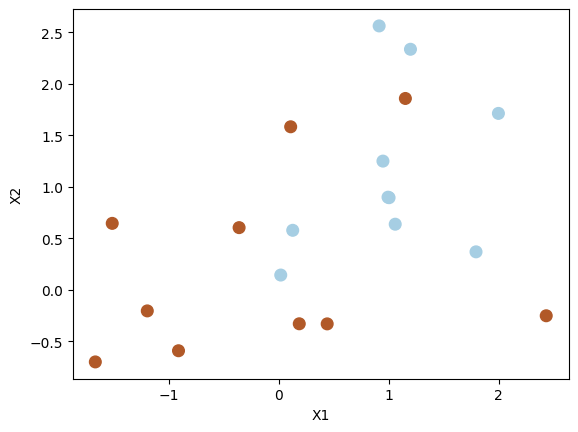

In [11]:
# Plot the data to see whether the classes are linearly separable:
plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=mpl.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Nope; not linear. Next, we fit the support vector classifier:

In [12]:
svc = SVC(C=1, kernel='linear')
svc.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


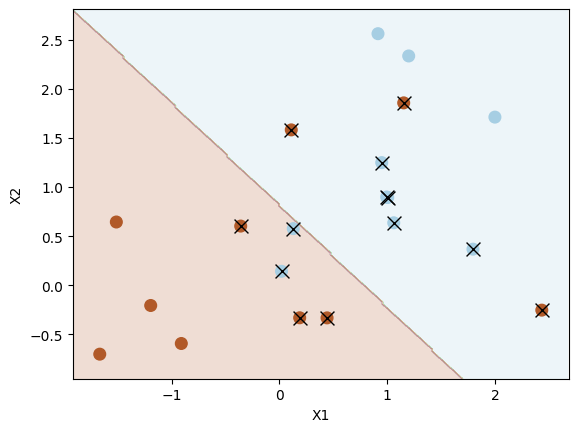

Number of support vectors:  13


In [13]:
plot_svc(svc, X, y)

+ The region of feature space that will be assigned to the −1 class is shown in light blue, and the region that will be assigned to the +1 class is shown in brown. 
+ The decision boundary between the two classes is linear (because we used the argument ${\tt kernel="linear"}$).

+ The support vectors are plotted with crosses and the remaining observations are plotted as circles; 
+ We see here that there are 13 support vectors. 
+ We can determine their identities as follows:

In [14]:
svc.support_

array([10, 11, 13, 14, 15, 16, 17,  0,  1,  2,  4,  6,  8], dtype=int32)

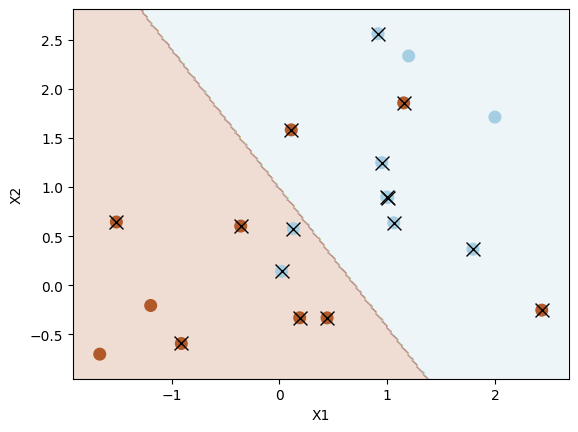

Number of support vectors:  16


In [15]:
# Use a smaller value of the C parameter
svc2 = SVC(C=0.1, kernel='linear')
svc2.fit(X, y)
plot_svc(svc2, X, y)

+ Now that a smaller value of the ${\tt c}$ parameter is being used, we obtain a larger number of support vectors, because the margin is now **wider**.
+ The ${\tt sklearn.grid\_search}$ module includes a a function ${\tt GridSearchCV()}$ to perform cross-validation. 
+ In order to use this function, we pass in relevant information about the set of models that are under consideration. 


In [16]:
# Perform 10-fold cross-validation to compare SVCs with a linear kernel, using a range of values of the cost parameter:
from sklearn.model_selection import GridSearchCV

# Select the optimal C parameter by cross-validation
tuned_parameters = [{'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}]
clf = GridSearchCV(SVC(kernel='linear'), tuned_parameters, cv=10, scoring='accuracy')
clf.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='linear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.001, 0.01, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramete

In [17]:
# the cross-validation errors for each of these models:
clf.cv_results_

{'mean_fit_time': array([0.00035448, 0.00030553, 0.00030344, 0.00030212, 0.00036852,
        0.00035028, 0.00042548]),
 'std_fit_time': array([5.77525198e-05, 5.24872965e-06, 4.89199834e-06, 6.10444688e-06,
        5.86994144e-05, 2.55652764e-05, 6.13375712e-05]),
 'mean_score_time': array([0.0003284 , 0.00029919, 0.00030055, 0.00030184, 0.00032456,
        0.00031517, 0.00032365]),
 'std_score_time': array([3.78139984e-05, 9.33277034e-06, 7.69704390e-06, 5.39585018e-06,
        3.54630386e-05, 1.19463887e-05, 2.85316919e-05]),
 'param_C': masked_array(data=[0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 100.0],
              mask=[False, False, False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'C': 0.001},
  {'C': 0.01},
  {'C': 0.1},
  {'C': 1},
  {'C': 5},
  {'C': 10},
  {'C': 100}],
 'split0_test_score': array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]),
 'split1_test_score': array([0.5, 0.5, 0.5, 0. , 0. , 0. , 0. ]),
 'split2_test_score': array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5

In [18]:
# the best parameters obtained
clf.best_params_

{'C': 0.001}

In [19]:
# generate a test data set:
np.random.seed(1)
X_test = np.random.randn(20,2)
y_test = np.random.choice([-1,1], 20)
X_test[y_test == 1] = X_test[y_test == 1]-1

In [20]:
# predict the class labels of these test observations. 
svc2 = SVC(C=0.001, kernel='linear')
svc2.fit(X, y)
y_pred = svc2.predict(X_test)
pd.DataFrame(confusion_matrix(y_test, y_pred), index=svc2.classes_, columns=svc2.classes_)

,-1,1
-1,2,6
1,0,12


+ 14 of the test observations are correctly classified.
+ Consider a situation in which the two classes are linearly separable. 
+ Then we can find a separating hyperplane using the  ${\tt svm()}$  function. 
+ First we'll give our simulated data a little nudge so that they are linearly separable:

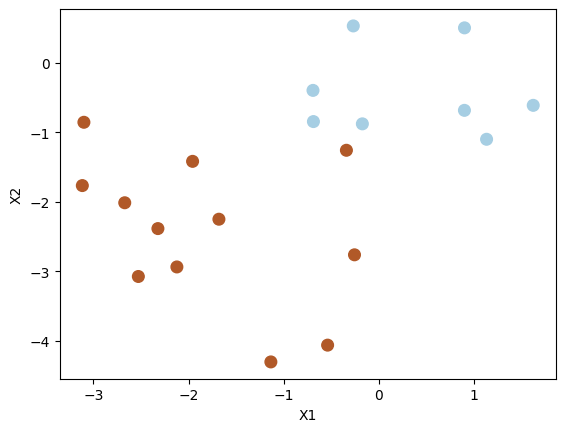

In [21]:
X_test[y_test == 1] = X_test[y_test == 1] -1
plt.scatter(X_test[:,0], X_test[:,1], s=70, c=y_test, cmap=mpl.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

+ the observations are **just barely linearly** separable.
+ Fit the support vector classifier and plot the resulting hyperplane, using a very large value of ${\tt cost}$ so that no observations are misclassified.

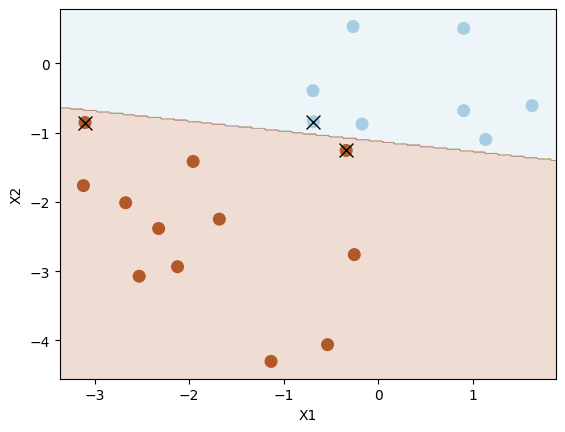

Number of support vectors:  3


In [22]:
svc3 = SVC(C=1e5, kernel='linear')
svc3.fit(X_test, y_test)
plot_svc(svc3, X_test, y_test)

+ No training errors were made and only three support vectors were used.
+ However, we can see from the figure that the margin is very narrow (because the observations that are **not** support vectors, indicated as circles, are very close to the decision boundary). 
+ It seems likely that this model will perform poorly on test data. 
+ Let's try a smaller value of ${\tt cost}$:

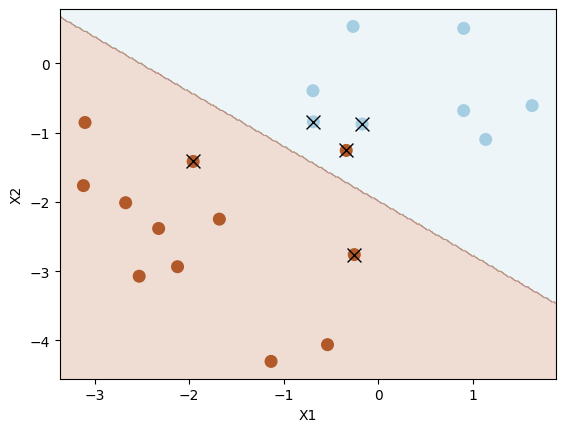

Number of support vectors:  5


In [23]:
svc4 = SVC(C=1, kernel='linear')
svc4.fit(X_test, y_test)
plot_svc(svc4, X_test, y_test)

+ Using ${\tt cost=1}$, we misclassify a training observation, but we also obtain a much wider margin and make use of five support vectors. 
+ It seems likely that this model will perform better on test data than the model with ${\tt cost=1e5}$.

## Support Vector Machines


In [ ]:
Image('images2/pw98.png', width =600)

FileNotFoundError: No such file or directory: 'images/pw98.png'

FileNotFoundError: No such file or directory: 'images/pw98.png'

<IPython.core.display.Image object>


### Classification with Non-linear Decision Boundaries
+ For data that has a non-linear separating hyperplane, something different must be done.
+ We can transform the variables as in previous chapters - squaring them, creating interaction terms, etc... 
+ For example, instead of fitting a support vector classifier using $p$ features,
$$X_1,X_2, \ldots, X_p$$
we could instead fit using $2p$ features
$$X_1,X_1,^2, X_2, X_2^2, \ldots, X_p, X_p^2$$
+ Then the opitimization problem will be
$$    \max_{\beta_0, \beta_{11}, \beta_{12},\ldots, \beta_{p1}, \beta_{p2}, \epsilon_1, \ldots , \epsilon_n, M}{M} $$
$$   \textrm{subject to } \sum_{j=1}^p\sum_{k=1}^2{\beta_{jk}^2} = 1 $$
$$   y_i\left(\beta_0 + \sum_{j=1}^p{\beta_{j1} x_{ij}} + \sum_{j=1}^p{\beta_{j2} x_{ij}^2}\right) \geq M(1-\epsilon_i) $$
$$  \epsilon_i \geq 0, \quad \sum_{i=1}^n{\epsilon_i} \leq C $$
  which will lead to a non-linear decision boundary.
  
### The SVM
+ Extension of SVC that results from enlarging feature space by using kernels in an efficient manner without doing those transformations. 
+ The solution to SVM's involves only inner products of the observations. 
+ The **inner products** of two $r$-vectors $a$ and $b$ is defined by 
$$\langle a, b \rangle = \sum_{i=1}^r{a_i b_i}$$
Thus the innerproduct of two observations $x_i, x_{i^\prime}$ is
$$\langle x_i, x_{i^\prime} \rangle = \sum_{j=1}^p{x_{ij}, x_{{i^\prime}j}}$$
+ The linear SVC can the be represented as
$$f(x) = \beta_0 + \sum_{i=1}^n{\alpha_i \langle x, x_i \rangle}$$
where there are $n$ parameters $\alpha_i, \; i=1, \ldots, n$, one per training observation.
+ To estimate these parameters, all we need are the ${n \choose 2}$ inner products $x_i, x_{i^\prime}$ between all pairs of training observations.
+ $\alpha_i$ is nonzero only for the support vectors in the solution. Therefore, we can write 
$$f(x) = \beta_0 + \sum_{i \in S}{\alpha_i \langle x, x_i \rangle}$$
where $S$ is the collection of indices of those support points.
+ The decision boundary is just a weighted sum of the inner product between observations that are the support vectors. 
+ The inner product can be replaced with a kernel function, $K(x_i, x_{i^\prime})$, which is a function that quantifies the similarity of two observations (measure a degree of closeness). 
+ So the further the two points in the kernel function are, the smaller the result of the kernel calculation.
+ Linear kernel is just the standard inner product. 
+ Polynomial kernel is linear kernel taken to the power of a chosen polynomial. 
$$K(x_i, x_{i^\prime}) = (1+\sum_{j=1}^p{x_{ij} x_{{i^\prime}j}})^d$$
+ The radial basis function is proportional to the squared distance between points. 
$$K(x_i, x_{i^\prime}) = \exp(-\gamma\sum_{j=1}^p{(x_{ij} -  x_{{i^\prime}j})^2})$$

+ Kernels allow for very high dimensional (infinite with radial basis function) feature space enlargement without actually going into that space.


In [ ]:
Image('images2/pw99.png', width =600)

FileNotFoundError: No such file or directory: 'images/pw99.png'

FileNotFoundError: No such file or directory: 'images/pw99.png'

<IPython.core.display.Image object>

### Lab
+ Fit an SVM using a **non-linear kernel** using the ${\tt SVC()}$ function. However, now we use a different value of the parameter kernel.
+ To fit an SVM with a polynomial kernel we use ${\tt kernel="poly"}$, and to fit an SVM with a radial kernel we use ${\tt kernel="rbf"}$. 
+ In the former case we also use the ${\tt degree}$ argument to specify a degree for the polynomial kernel, and in the latter case we use ${\tt gamma}$ to specify a value of $\gamma$ for the radial basis kernel.

+ Let's generate some data with a non-linear class boundary:

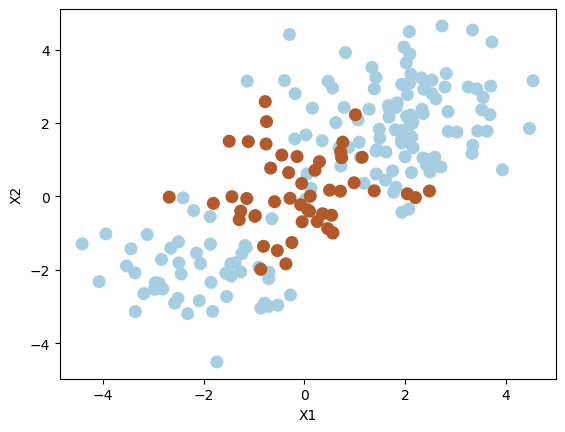

In [26]:
from sklearn.model_selection import train_test_split

np.random.seed(8)
X = np.random.randn(200,2)
X[:100] = X[:100] +2
X[101:150] = X[101:150] -2
y = np.concatenate([np.repeat(-1, 150), np.repeat(1,50)])

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, random_state=2)

plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=mpl.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

+ One class is kind of stuck in the middle of another class. This suggests that we might want to use a **radial kernel** in our SVM. 
+ Fit the training data using the ${\tt SVC()}$ function with a radial kernel and $\gamma = 1$:

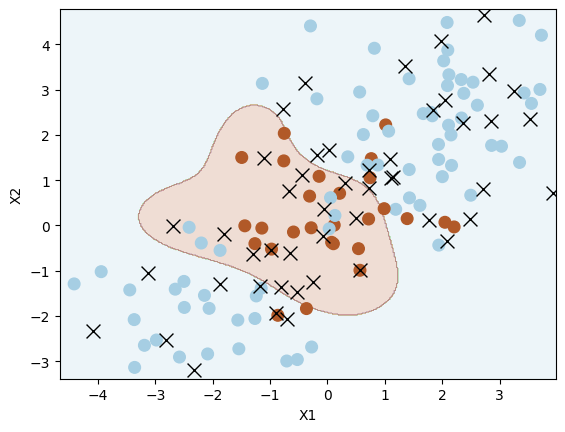

Number of support vectors:  51


In [27]:
svm = SVC(C=1.0, kernel='rbf', gamma=1)
svm.fit(X_train, y_train)
plot_svc(svm, X_test, y_test)

+ The plot shows that the resulting SVM has a decidedly non-linear boundary. 
+ There are a fair number of training errors in this SVM fit. 
+ Increase the value of cost to reduce the number of training errors:

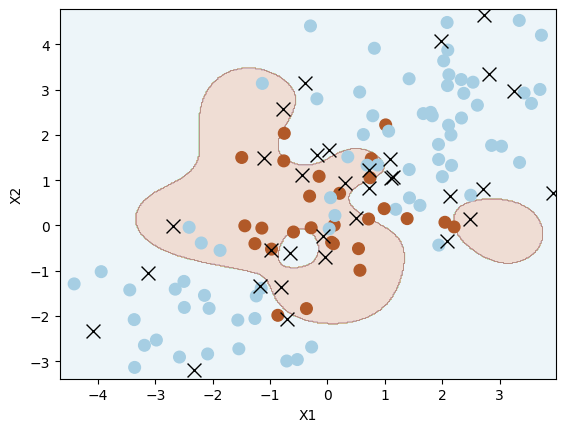

Number of support vectors:  36


In [28]:
# Increasing C parameter, allowing more flexibility
svm2 = SVC(C=100, kernel='rbf', gamma=1.0)
svm2.fit(X_train, y_train)
plot_svc(svm2, X_test, y_test)

+ However, this comes at the price of a more irregular decision boundary that seems to be at risk of overfitting the data. 
+ We can perform cross-validation using ${\tt GridSearchCV()}$ to select the best choice of $\gamma$ and cost for an SVM with a radial kernel:

In [29]:
tuned_parameters = [{'C': [0.01, 0.1, 1, 10, 100],
                     'gamma': [0.5, 1,2,3,4]}]
clf = GridSearchCV(SVC(kernel='rbf'), tuned_parameters, cv=10, scoring='accuracy')
clf.fit(X_train, y_train)
clf.best_params_

{'C': 10, 'gamma': 0.5}

+ The best choice of parameters involves ${\tt cost=1}$ and ${\tt gamma=0.5}$. 
+ Plot the resulting fit using the ${\tt plot\_svc()}$ function, and view the test set predictions for this model by applying the ${\tt predict()}$ function to the test data:

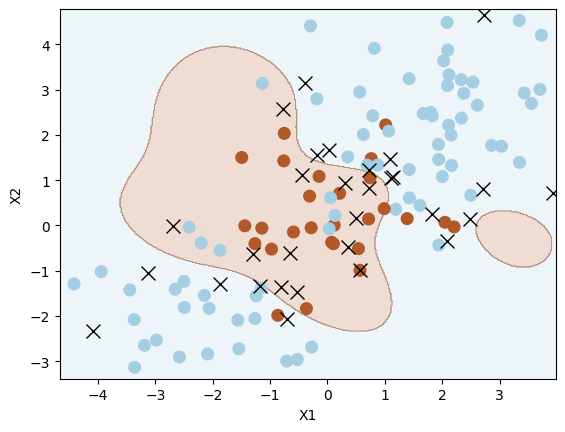

Number of support vectors:  32
[[66  7]
 [ 6 21]]
0.87


In [30]:
plot_svc(clf.best_estimator_, X_test, y_test)
print(confusion_matrix(y_test, clf.best_estimator_.predict(X_test)))
print(clf.best_estimator_.score(X_test, y_test))

85% of test observations are correctly classified by this SVM.

### ROC Curves

The ${\tt auc()}$ function from the ${\tt sklearn.metrics}$ package can be used to produce ROC curves such as those we saw in lecture:

In [31]:
from sklearn.metrics import auc
from sklearn.metrics import roc_curve

Let's start by fitting two models, one more flexible than the other:

In [32]:
# More constrained model
svm3 = SVC(C=1, kernel='rbf', gamma=1)
svm3.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [33]:
# More flexible model
svm4 = SVC(C=1, kernel='rbf', gamma=50)
svm4.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",50
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


+ SVMs and SVCs output class labels for each observation.
+ However, it is also possible to obtain fitted values for each observation, which are the numerical scores used to obtain the class labels. 
+ For instance, in the case of a SVC, the fitted value for an observation $X = (X_1,X_2, . . .,X_p)^T$ takes the form $\hat\beta_0 + \hat\beta_1X_1 + \hat\beta_2X_2 + . . . + \hat\beta_pX_p$.

+ In essence, the sign of the fitted value determines on which side of the decision boundary the observation lies. 
+ Therefore, the relationship between the fitted value and the class prediction for a given observation is simple: if the fitted value exceeds zero then the observation is assigned to one class, and if it is less than zero than it is assigned to the other.

+ In order to obtain the fitted values for a given SVM model fit, we use the ${\tt .decision\_function()}$ method of the SVC:

In [34]:
y_train_score3 = svm3.decision_function(X_train)
y_train_score4 = svm4.decision_function(X_train)

Now we can produce the ROC plot to see how the models perform on both the training and the test data:

In [35]:
y_train_score3

array([-1.22860178, -1.05692137, -0.3142208 ,  0.78784978, -1.00010268,
       -0.76246564, -1.0137596 , -1.26423928, -1.01001472,  0.39346089,
       -1.06588756, -0.04580111, -0.99994116,  0.98733568, -0.99952667,
        0.25808491,  0.83473099, -1.00003112,  0.99990628, -1.00030439,
       -0.87759622, -1.08400321, -1.02223421, -1.00007572, -1.50585928,
       -1.40655313,  1.0000108 , -1.34577625, -1.00461852, -0.9999493 ,
       -1.06863734, -1.01360297, -1.02282425, -1.08546812, -1.06701029,
       -1.00008158, -1.00007304, -1.00044989, -1.07852417, -1.1324137 ,
       -1.0225526 ,  1.00027947, -1.01615428, -1.01610638,  1.05195277,
       -1.00002038, -0.99994116, -1.03320182,  1.01363266, -1.00020267,
       -1.02465047,  1.15980244, -0.99970244,  0.53867317,  1.16401969,
       -0.96324627, -1.00836262, -1.06227265,  1.08735028, -1.02003678,
       -1.00051512, -1.00972831, -0.7266115 ,  0.60799437, -1.16099504,
       -0.56064887, -0.44061502, -0.9997617 , -1.03873697, -1.12

<>:11: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:12: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:24: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:25: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:11: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:12: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:24: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences wil

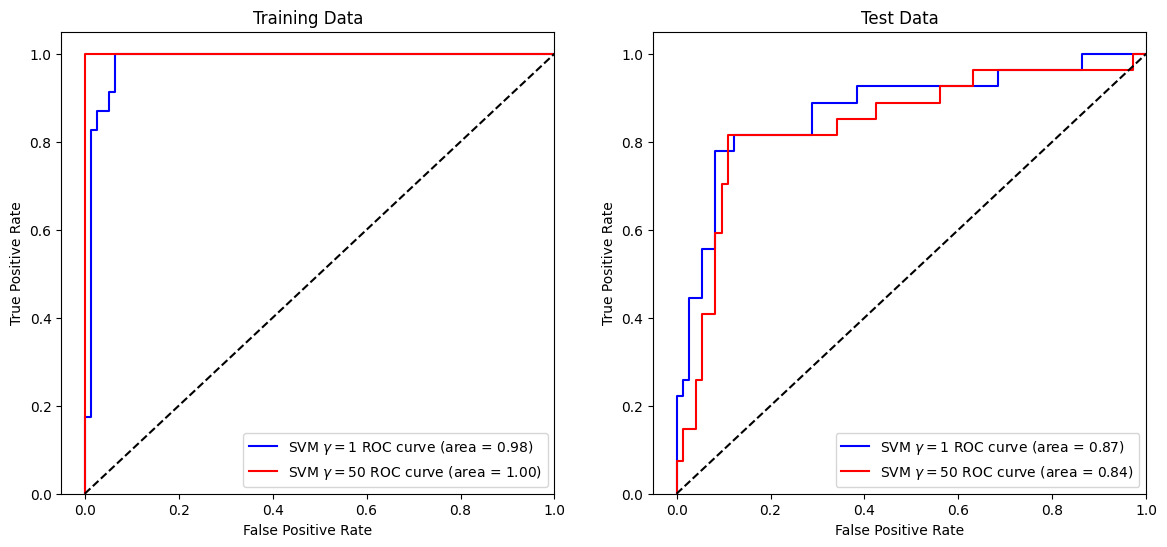

In [36]:
y_train_score3 = svm3.decision_function(X_train)
y_train_score4 = svm4.decision_function(X_train)

false_pos_rate3, true_pos_rate3, _ = roc_curve(y_train, y_train_score3)
roc_auc3 = auc(false_pos_rate3, true_pos_rate3)

false_pos_rate4, true_pos_rate4, _ = roc_curve(y_train, y_train_score4)
roc_auc4 = auc(false_pos_rate4, true_pos_rate4)

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14,6))
ax1.plot(false_pos_rate3, true_pos_rate3, label='SVM $\gamma = 1$ ROC curve (area = %0.2f)' % roc_auc3, color='b')
ax1.plot(false_pos_rate4, true_pos_rate4, label='SVM $\gamma = 50$ ROC curve (area = %0.2f)' % roc_auc4, color='r')
ax1.set_title('Training Data')

y_test_score3 = svm3.decision_function(X_test)
y_test_score4 = svm4.decision_function(X_test)

false_pos_rate3, true_pos_rate3, _ = roc_curve(y_test, y_test_score3)
roc_auc3 = auc(false_pos_rate3, true_pos_rate3)

false_pos_rate4, true_pos_rate4, _ = roc_curve(y_test, y_test_score4)
roc_auc4 = auc(false_pos_rate4, true_pos_rate4)

ax2.plot(false_pos_rate3, true_pos_rate3, label='SVM $\gamma = 1$ ROC curve (area = %0.2f)' % roc_auc3, color='b')
ax2.plot(false_pos_rate4, true_pos_rate4, label='SVM $\gamma = 50$ ROC curve (area = %0.2f)' % roc_auc4, color='r')
ax2.set_title('Test Data')

for ax in fig.axes:
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([-0.05, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc="lower right")

plt.show()


## Multi-Class SVM
+ Two different approaches for $K$ classes where $K > 2$. 

**One vs One** 
+ Also known as **all-pairs** approach.
+ Constructs ${K \choose 2}$ SVMs, each of which compares a pair of class.
+ Test observations are assigned to the class which it was most frequently assigned. 

**One vs All** 
+ Constructs $K$ SVMs, each time comparing one of the $K$ class to the remaining $K-1$ classes. 
+ The test observation is belong to the class with the greatest distance from the hyperplane, i.e., $\beta_{0k} + \beta_{1k}x_1^* + \beta_{2k}x_2^* +  \ldots + \beta_{pk}x_p^*$ is largest.

### Lab
+ If the response is a factor containing more than two levels, then the ${\tt svm()}$function will perform multi-class classification using the one-versus-one approach.
+ We explore that setting here by generating a third class of observations:

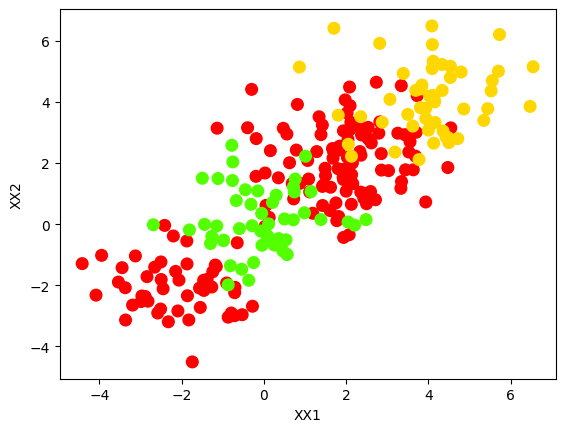

In [37]:
np.random.seed(8)
XX = np.vstack([X, np.random.randn(50,2)])
yy = np.hstack([y, np.repeat(0,50)])
XX[yy ==0] = XX[yy == 0] +4

plt.scatter(XX[:,0], XX[:,1], s=70, c=yy, cmap=plt.cm.prism)
plt.xlabel('XX1')
plt.ylabel('XX2')
plt.show()

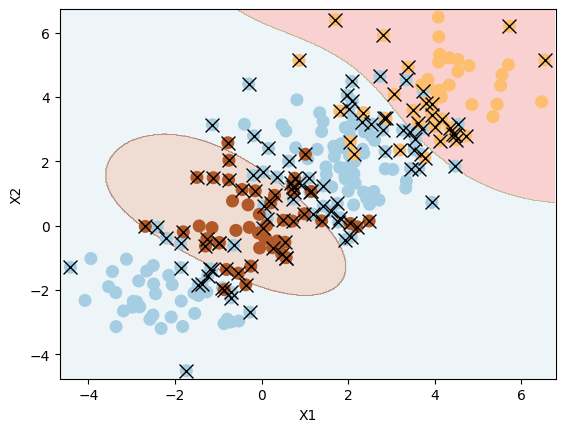

Number of support vectors:  128


In [38]:
# Fitting an SVM to multiclass data uses identical syntax to fitting a simple two-class model:
svm5 = SVC(C=1, kernel='rbf')
svm5.fit(XX, yy)
plot_svc(svm5, XX, yy)

## Application to Handwritten Letter Data

+ We now examine [`Optical Recognition of Handwritten Digits Data Set`](http://archive.ics.uci.edu/ml/datasets/optical+recognition+of+handwritten+digits), which contains 5,620 samples of handwritten digits 0..9. 
+ You can use these links to download the [training data](http://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tra) and [test data](http://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tes), and then we'll load them into python:

In [39]:
X_train = pd.read_csv('data/optdigits.tra', header=None)
y_train = X_train[64]
X_train = X_train.drop(X_train.columns[64], axis=1)

X_test = pd.read_csv('data/optdigits.tes', header=None)
y_test = X_test[64]
X_test = X_test.drop(X_test.columns[64], axis=1)

In [40]:
y_train

0       0
1       0
2       7
3       4
4       6
       ..
3818    9
3819    4
3820    6
3821    6
3822    7
Name: 64, Length: 3823, dtype: int64

In [41]:
# Look at the dimensions of this dataset:
print(X_train.shape)
print(X_test.shape)

(3823, 64)
(1797, 64)


+ This data set consists of preprocessed images of handwriting samples gathered from 43 different people. 
+ Each image was converted into an 8x8 matrix (64 pixels), which was then flattened into a vector of 64 numeric values. 
+ The final column contains the class label for each digit.

+ The training and test sets consist of 3,823 and 1,797 observations respectively. 
+ Let's see what one of these digits looks like:

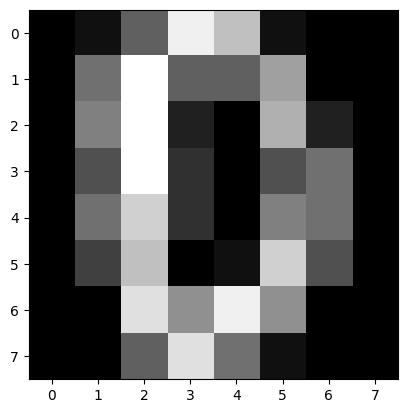

In [42]:
plt.imshow(X_train.values[0].reshape(8,8), cmap="gray") 
plt.show()

In [43]:
y_train[0]

np.int64(0)

In [44]:
# Let's start with a linear kernel to see how we do:
svc = SVC(kernel='linear', C=10)
svc.fit(X_train, y_train)

# Print a nice confusion matrix
cm = confusion_matrix(y_train, svc.predict(X_train))
cm_df = pd.DataFrame(cm.T, index=svc.classes_, columns=svc.classes_)
print(cm_df)

     0    1    2    3    4    5    6    7    8    9
0  376    0    0    0    0    0    0    0    0    0
1    0  389    0    0    0    0    0    0    0    0
2    0    0  380    0    0    0    0    0    0    0
3    0    0    0  389    0    0    0    0    0    0
4    0    0    0    0  387    0    0    0    0    0
5    0    0    0    0    0  376    0    0    0    0
6    0    0    0    0    0    0  377    0    0    0
7    0    0    0    0    0    0    0  387    0    0
8    0    0    0    0    0    0    0    0  380    0
9    0    0    0    0    0    0    0    0    0  382


+ We see that there are **no training errors**. 
+ This is not surprising, because the large number of variables relative to the number of observations implies that it is easy to find hyperplanes that fully separate the classes.
+ We are most interested not in the support vector classifier’s performance on the training observations, but rather its performance on the test observations:

In [45]:
cm = confusion_matrix(y_test, svc.predict(X_test))
print(pd.DataFrame(cm.T, index=svc.classes_, columns=svc.classes_))
print(svc.score(X_test, y_test))

     0    1    2    3    4    5    6    7    8    9
0  177    0    0    1    0    0    0    0    0    1
1    0  178    7    0    0    0    0    0    9    0
2    0    0  170    5    0    1    0    0    1    0
3    0    0    0  171    0    0    0    0    5    4
4    0    0    0    0  180    0    1    1    0    1
5    1    0    0    2    0  180    0    7    2    3
6    0    3    0    0    0    0  179    0    0    0
7    0    0    0    2    0    0    0  165    0    0
8    0    1    0    1    1    0    1    0  157    1
9    0    0    0    1    0    1    0    6    0  170
0.9610461880912632


+ We see that using cost = 10 yields just 70 test set errors on this data. 
+ Now try using the  ${\tt GridSearchCV()}$  function to select an optimal value for ${\tt c}$. Consider values in the range 0.01 to 100:

In [46]:
# Select the optimal C parameter by cross-validation
tuned_parameters = [{'C': [0.01, 0.1, 1, 5, 10, 100]}]
clf = GridSearchCV(SVC(kernel='linear'), tuned_parameters, cv=10, scoring='accuracy')
clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='linear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter 

In [47]:
clf.best_params_

{'C': 0.01}

In [48]:
svc2 = SVC(C=0.01, kernel='linear')
svc2.fit(X_train, y_train)
cm2 = confusion_matrix(y_test, svc2.predict(X_test))
print(pd.DataFrame(cm2.T, index=svc2.classes_, columns=svc2.classes_))
print(svc2.score(X_test, y_test))

     0    1    2    3    4    5    6    7    8    9
0  177    0    0    1    0    0    0    0    0    1
1    0  178    7    0    0    0    0    0    8    1
2    0    0  170    5    0    1    0    0    1    0
3    0    0    0  170    0    0    0    0    3    4
4    0    0    0    0  180    0    1    1    0    1
5    1    0    0    3    0  180    0    7    2    3
6    0    2    0    0    0    0  179    0    0    0
7    0    0    0    2    0    0    0  165    0    0
8    0    1    0    1    1    0    1    0  159    1
9    0    1    0    1    0    1    0    6    1  169
0.9610461880912632


# Exercises

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 1

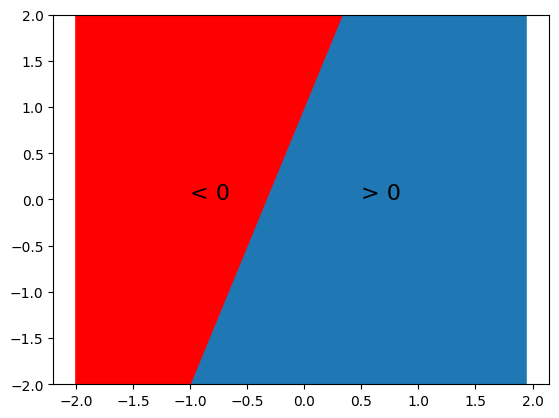

In [50]:
section = np.arange(-2, 2, 1/20.)
f = lambda x: 1 + 3*x
plt.fill_between(section, f(section), y2=-2)
plt.fill_between(section, f(section), y2=2, color='r')
plt.text(.5, 0, "> 0", fontsize=16)
plt.text(-1, 0, "< 0", fontsize=16)
plt.ylim(-2, 2);

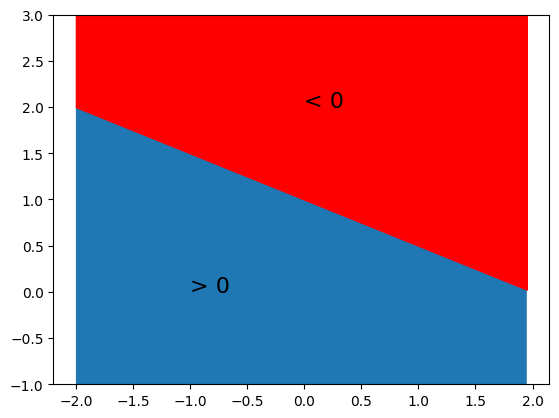

In [51]:
section = np.arange(-2, 2, 1/20.)
f = lambda x: 1 - .5*x
plt.fill_between(section, f(section), y2=-1)
plt.fill_between(section, f(section), y2=3, color='r')
plt.text(0, 2, "< 0", fontsize=16)
plt.text(-1, 0, "> 0", fontsize=16)
plt.ylim(-1, 3);

# 2

(-1.0, 5.0)

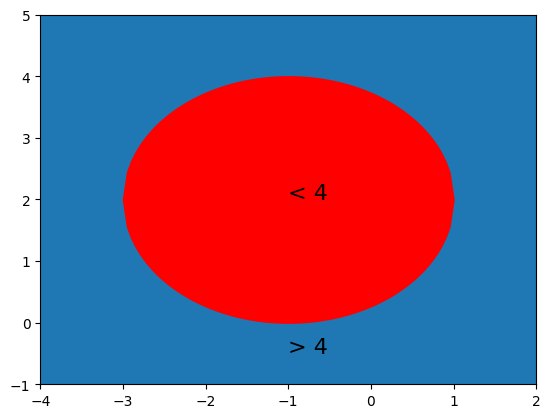

In [52]:
section = np.arange(-3, 1.05, 1/20.)
f = lambda x: 2 + np.sqrt(4 - (1 + x)**2)
g = lambda x: 2 - np.sqrt(4 - (1 + x)**2)
plt.fill_between(np.arange(-5, 5), -10, 10)
plt.fill_between(section, g(section), f(section), color='r')
plt.text(-1, 2, "< 4", fontsize=16)
plt.text(-1, -.5, "> 4", fontsize=16)
plt.xlim(-4, 2)
plt.ylim(-1, 5)

c) 
* (0, 0) = blue
* (-1, 1) = red  
* (2, 2) = blue
* (3, 8) = blue

d) x1, x2, x1^2 and x^2 are linear in 4 dimensions. When it is projected down to 2 dimensions we get a circle.

# 3

In [53]:
df = pd.DataFrame(np.array([[3, 4, -1], [2, 2, -1], [4, 4, -1], [1, 4, -1], [2, 1, 1], [4, 3, 1], [4, 1, 1]]), 
             columns=['x1', 'x2', 'y'])
df['color'] = df['y'].map({1: 'r', -1:'b'})
df

,x1,x2,y,color
0,3,4,-1,b
1,2,2,-1,b
2,4,4,-1,b
3,1,4,-1,b
4,2,1,1,r
5,4,3,1,r
6,4,1,1,r


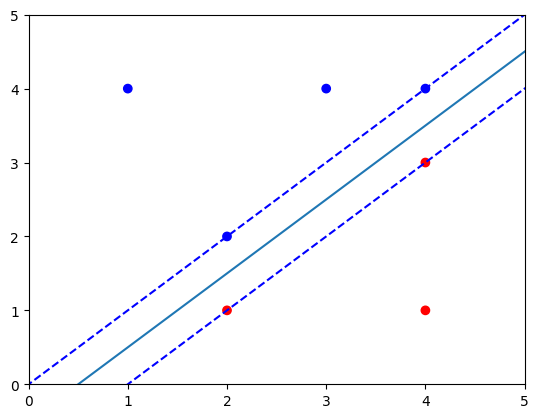

In [54]:
plt.scatter(df['x1'], df['x2'], color=df['color']);
# maximum separating hyperplane is x1 - x2 - .5 = 0
section = np.arange(-3, 8)
f = lambda x: x - .5
plt.plot(section, f(section))
plt.plot(section, f(section) + .5, 'b--')
plt.plot(section, f(section) - .5, 'b--')
plt.ylim(0, 5)
plt.xlim(0, 5);

d) Classification rule if x1 - x2 - .5 > 0 then red else blue

In [55]:
# e) margin is distance from support vector to line.
print("margin is", .5 / np.sqrt(2))

margin is 0.35355339059327373


f) point (4, 1) is far from the hyperplane and changing it slightly will have no effect on it.

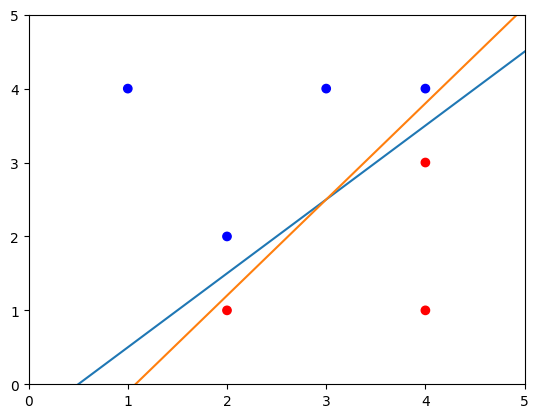

In [56]:
#g Green line is non-optimal hyperplane. Still separates data but worse margin
plt.scatter(df['x1'], df['x2'], color=df['color']);
# maximum separating hyperplane is x1 - x2 - .5 = 0
section = np.arange(-3, 8)
f = lambda x: x - .5
g = lambda x: 1.3 * x - 1.4
plt.plot(section, f(section))
plt.plot(section, g(section))
plt.ylim(0, 5)
plt.xlim(0, 5);

# 4

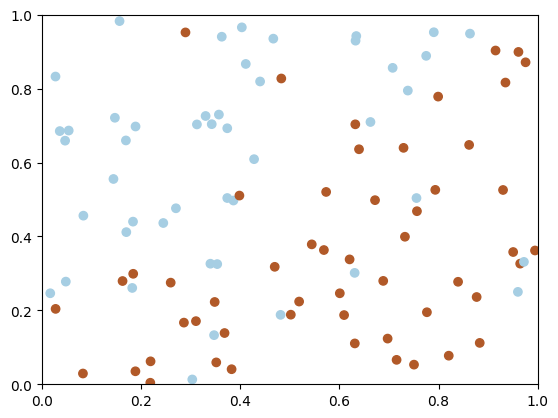

In [57]:
# create fake data where true boundary is x2 - x1 = 0
X = np.random.rand(100, 2)
d = 3 * (X[:, 0] - X[:, 1])
n = np.random.randn(100)
y = np.where(n > d, 0, 1)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
plt.xlim(0, 1)
plt.ylim(0, 1);

In [58]:
from sklearn.svm import SVC

In [59]:
clf = SVC(kernel='linear', C=10)

In [60]:
clf.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [61]:
clf.intercept_, clf.coef_

(array([0.29400334]), array([[ 3.71434395, -3.87367512]]))

(0.0, 1.0)

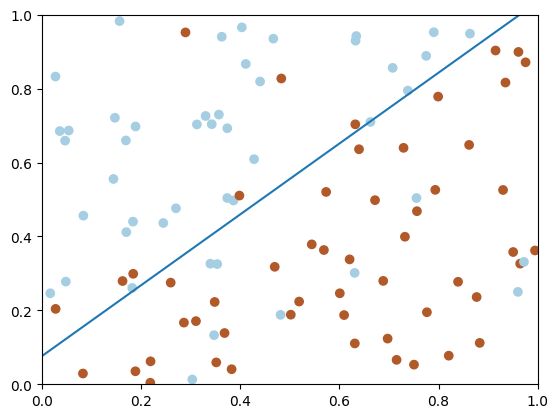

In [62]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
section = np.arange(0, 1, .01)

beta0 = clf.intercept_
beta1 = clf.coef_[0, 0]
beta2 = clf.coef_[0, 1]

f = lambda x: (beta0 + beta1 * x) / -beta2
plt.plot(section, f(section))
plt.xlim(0, 1)
plt.ylim(0, 1)

Use sklearn code found [here](http://scikit-learn.org/stable/auto_examples/svm/plot_iris.html) to plot decision boundaries for svm

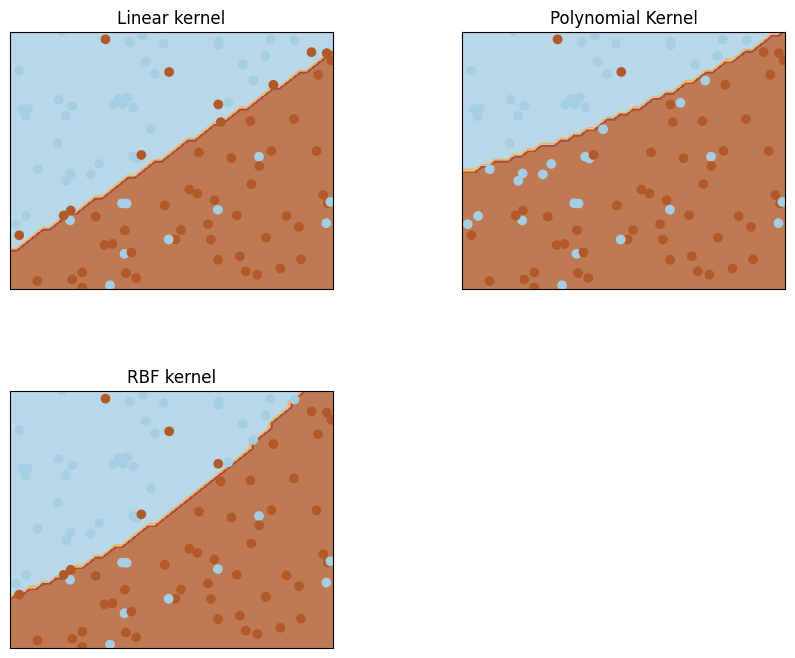

In [63]:
h = .02  # step size in the mesh

C = 1.0  # SVM regularization parameter
svc = SVC(kernel='linear', C=C).fit(X, y)
rbf_svc = SVC(kernel='rbf', gamma=0.7, C=C).fit(X, y)
poly_svc = SVC(kernel='poly', degree=3, C=C).fit(X, y)

# create a mesh to plot in
xx, yy = np.meshgrid(np.arange(0, 1, h),
                     np.arange(0, 1, h))

# title for the plots
titles = ['Linear kernel',
          'Polynomial Kernel',
          'RBF kernel']

plt.figure(figsize=(10,8))
for i, clf in enumerate((svc, poly_svc, rbf_svc)):
    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    plt.subplot(2, 2, i + 1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])

In [64]:
#poly actually does worse. Might need some tuning
svc.score(X, y), rbf_svc.score(X, y), poly_svc.score(X, y)

(0.8, 0.84, 0.76)

# 5

In [65]:
X = np.random.rand(500,2) - .5
y = (X[:, 0] ** 2 - X[:, 1] ** 2 > 0) * 1

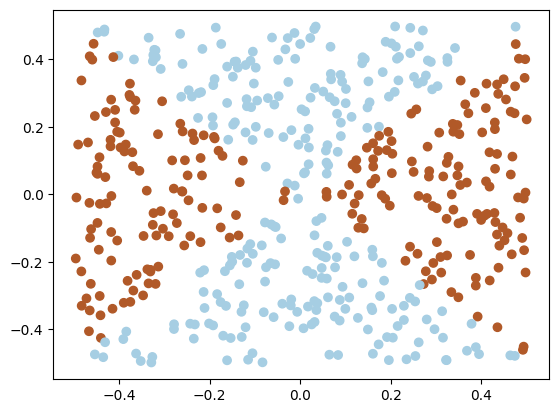

In [66]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired);

In [67]:
from sklearn.linear_model import LogisticRegression

In [68]:
log_clf = LogisticRegression()

In [69]:
log_clf.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

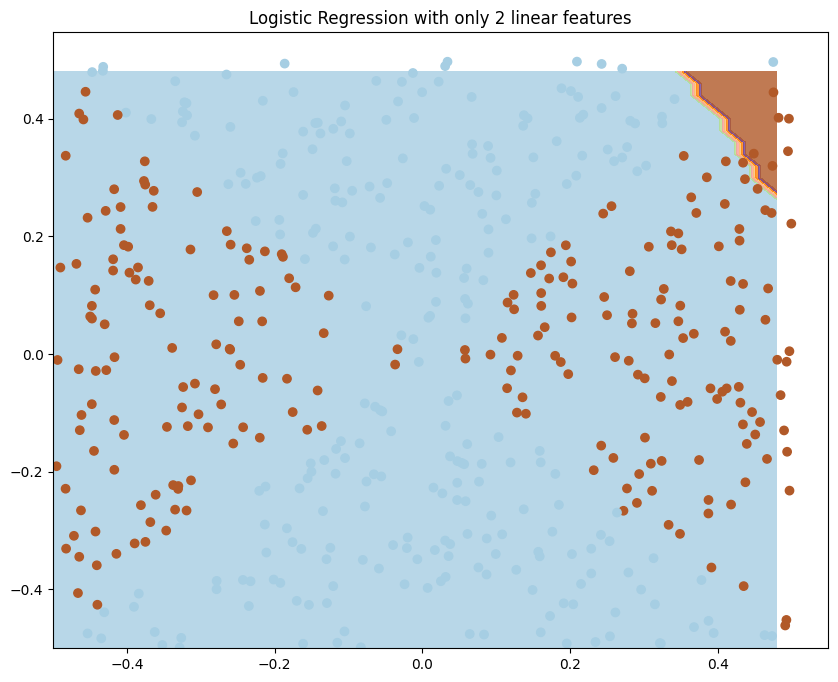

In [70]:
h = .02 

xx, yy = np.meshgrid(np.arange(-.5, .5, h),
                     np.arange(-.5, .5, h))

plt.figure(figsize=(10,8))
Z = log_clf.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
plt.title("Logistic Regression with only 2 linear features");

In [71]:
X_new = np.column_stack((X, X ** 2, X[:, 0] * X[:, 1]))

In [72]:
X_new.shape

(500, 5)

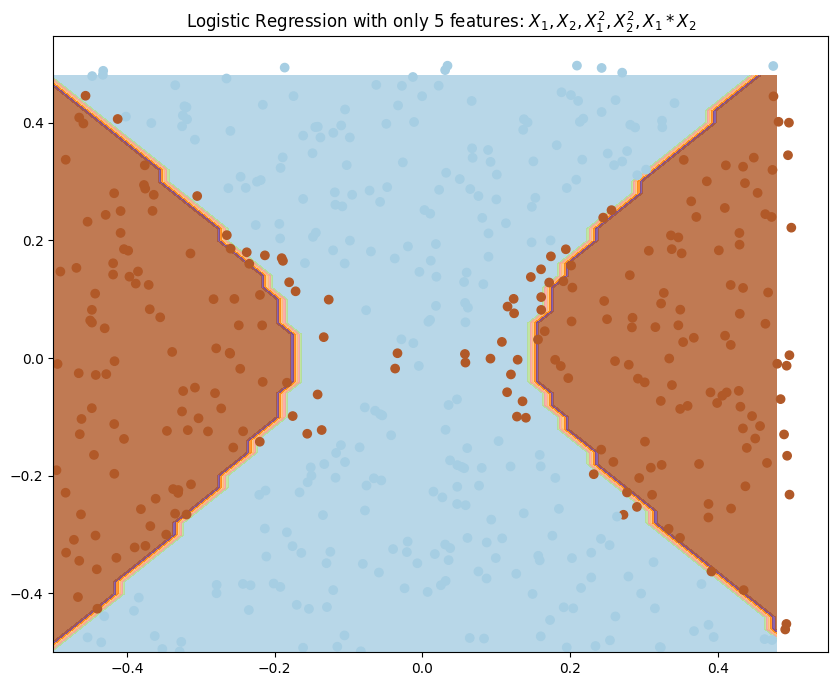

In [73]:
log_clf.fit(X_new, y)

h = .02 

xx, yy = np.meshgrid(np.arange(-.5, .5, h),
                     np.arange(-.5, .5, h))


plt.figure(figsize=(10,8))
Z = log_clf.predict(np.c_[xx.ravel(), yy.ravel(), xx.ravel()**2, yy.ravel()**2, xx.ravel() * yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
plt.title("Logistic Regression with only 5 features: $X_1, X_2, X_1^2, X_2^2, X_1*X_2$");

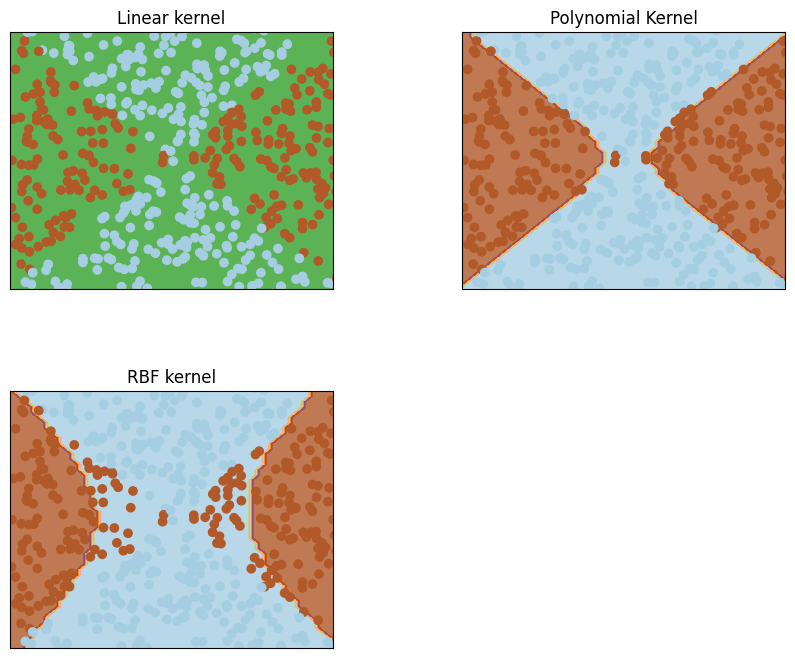

In [74]:
h = .02  # step size in the mesh

C = 1.0  # SVM regularization parameter
svc = SVC(kernel='linear', C=C).fit(X, y)
poly_svc = SVC(kernel='poly', degree=2, C=1).fit(X, y)
rbf_svc = SVC(kernel='rbf', gamma=.5, C=1).fit(X, y)

# create a mesh to plot in
xx, yy = np.meshgrid(np.arange(-.5, .5, h),
                     np.arange(-.5, .5, h))

# title for the plots
titles = ['Linear kernel',
          'Polynomial Kernel',
          'RBF kernel']

plt.figure(figsize=(10,8))
for i, clf in enumerate((svc, poly_svc, rbf_svc)):
    plt.subplot(2, 2, i + 1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])

Linear Kernel fails here, must use polynomial or rbf

# 6

In [75]:
# Make a linear decision boundary at x2 > .5
X = np.random.rand(500, 2)
y = (X[:, 1] > .5) * 1

X_train = X[:250]
X_test = X[250:]
y_train = y[:250]
y_test = y[250:]

(0.0, 1.0)

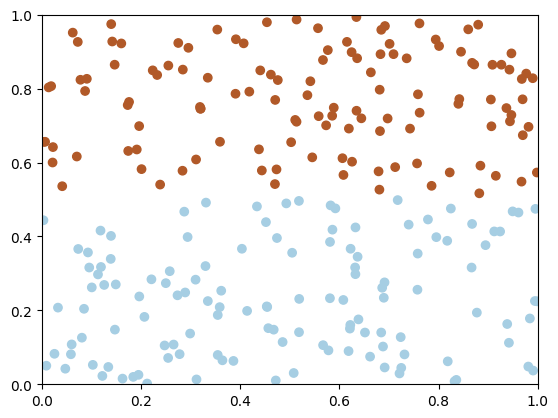

In [76]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Paired)
plt.xlim(0, 1)
plt.ylim(0, 1)

In [77]:
all_C = np.logspace(-2,-1, 100)
train_scores = []
test_scores = []
for c in all_C:
    svc = SVC(kernel='linear', C=c)
    svc.fit(X_train, y_train)
    train_scores.append(svc.score(X_train, y_train))
    test_scores.append(svc.score(X_test, y_test))

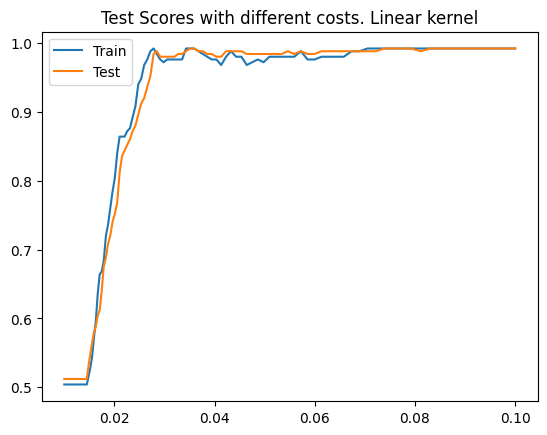

In [78]:
plt.plot(all_C, train_scores, label="Train")
plt.plot(all_C, test_scores, label="Test")
plt.title("Test Scores with different costs. Linear kernel")
plt.legend();

I don't think they worded this problem well. There needs to be a linearl separable data that has a wide enough decision boundary where points can be misclassified given new data.

# 7

In [79]:
auto = pd.read_csv("data/auto.csv")

In [80]:
auto['y'] = (auto['mpg'] > auto['mpg'].median()) * 1

In [81]:
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,y
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,0
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,0
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,0
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,0
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,0


In [82]:
X = pd.concat((pd.get_dummies(auto[['cylinders', 'origin', 'year']].astype(object)), 
               auto[['displacement', 'horsepower', 'weight', 'acceleration']],), axis=1)
y = auto['y']

In [83]:
X.head()

,cylinders_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8,origin_1,origin_2,origin_3,year_70,year_71,...,year_77,year_78,year_79,year_80,year_81,year_82,displacement,horsepower,weight,acceleration
0,False,False,False,False,True,True,False,False,True,False,...,False,False,False,False,False,False,307.0,130,3504,12.0
1,False,False,False,False,True,True,False,False,True,False,...,False,False,False,False,False,False,350.0,165,3693,11.5
2,False,False,False,False,True,True,False,False,True,False,...,False,False,False,False,False,False,318.0,150,3436,11.0
3,False,False,False,False,True,True,False,False,True,False,...,False,False,False,False,False,False,304.0,150,3433,12.0
4,False,False,False,False,True,True,False,False,True,False,...,False,False,False,False,False,False,302.0,140,3449,10.5


In [84]:
from sklearn.model_selection import cross_val_score

In [85]:
X_new = auto.iloc[:, 1:7]

In [86]:
for c in np.logspace(-4,1, 10):
    clf = SVC(kernel='linear', C=c)
    scores = cross_val_score(clf, X_new, y, n_jobs=-1, cv=5)
    print("Linear SVM with c={} has test accuracy of {}".format(round(c,4), round(scores.mean(), 3)))

Linear SVM with c=0.0001 has test accuracy of 0.898
Linear SVM with c=0.0004 has test accuracy of 0.905
Linear SVM with c=0.0013 has test accuracy of 0.9
Linear SVM with c=0.0046 has test accuracy of 0.88
Linear SVM with c=0.0167 has test accuracy of 0.878
Linear SVM with c=0.0599 has test accuracy of 0.873
Linear SVM with c=0.2154 has test accuracy of 0.87
Linear SVM with c=0.7743 has test accuracy of 0.86
Linear SVM with c=2.7826 has test accuracy of 0.87
Linear SVM with c=10.0 has test accuracy of 0.87


In [87]:
for c in np.logspace(-2,3, 10):
    gamma = .00001
    clf = SVC(kernel='rbf', gamma=gamma, C=c)
    scores = cross_val_score(clf, X_new, y, n_jobs=-1, cv=5)
    print("RBF SVM with c={} and gamma = {} has test accuracy of {}".format(round(c,4), gamma, round(scores.mean(), 3)))

RBF SVM with c=0.01 and gamma = 1e-05 has test accuracy of 0.822
RBF SVM with c=0.0359 and gamma = 1e-05 has test accuracy of 0.88
RBF SVM with c=0.1292 and gamma = 1e-05 has test accuracy of 0.883
RBF SVM with c=0.4642 and gamma = 1e-05 has test accuracy of 0.88
RBF SVM with c=1.6681 and gamma = 1e-05 has test accuracy of 0.885
RBF SVM with c=5.9948 and gamma = 1e-05 has test accuracy of 0.883
RBF SVM with c=21.5443 and gamma = 1e-05 has test accuracy of 0.883
RBF SVM with c=77.4264 and gamma = 1e-05 has test accuracy of 0.898
RBF SVM with c=278.2559 and gamma = 1e-05 has test accuracy of 0.898
RBF SVM with c=1000.0 and gamma = 1e-05 has test accuracy of 0.89


Polynomial kernel not able to be solved in reasonable time